# 🎓 Smart Campus Recruitment System
## Model 3 — Personalized Job Recommender
### Two-Tower Neural Retrieval + FAISS ANN + XGBoost Re-ranker

---

### Datasets (add via Kaggle → + Add Data):
| # | Dataset | Kaggle slug | Role |
|---|---------|-------------|------|
| 1 | **1.3M LinkedIn Jobs & Skills 2024** | `asaniczka/1-3m-linkedin-jobs-and-skills-2024` | **Primary** — 1.3M jobs with skill tags, titles, companies, descriptions |
| 2 | **LinkedIn Job Postings 2023-2024** | `arshkon/linkedin-job-postings` | **Secondary** — richer metadata (salary, experience level, applies) |
| 3 | **Resume NER Dataset** | `dataturks/resume-entities-for-ner` | Resume corpus to simulate Model 1 output |

---

### Model 1 & Model 2 output schemas consumed here:
```
Model 1 (resume_parser.py) output:
  skills[], designations[], companies[], degree[], colleges[],
  certifications[], years_experience, location[], raw_text

Model 2 (resume_scorer.py) output:
  ats_score, section_scores{}, matched_keywords[], missing_keywords[],
  suggestions[], job_title, company
```

### Model 3 output schema:
```json
{
  "recommendations": [
    {
      "rank": 1,
      "job_id": "123",
      "title": "Senior Data Scientist",
      "company": "Google",
      "location": "Bangalore",
      "match_score": 91.3,
      "ats_score": 84.2,
      "semantic_similarity": 0.87,
      "matched_skills": ["python", "tensorflow"],
      "reason": "Strong match on skills and experience level",
      "apply_url": "https://..."
    }
  ],
  "total_jobs_scanned": 1300000,
  "retrieval_time_ms": 43
}
```

### Architecture:
```
┌─────────────────────────────────────────────────────────────┐
│  STAGE 1 — RETRIEVAL (fast, recall-focused)                │
│  Resume JSON ──► Resume Encoder (Sentence-BERT)            │
│  Job Corpus  ──► Job Encoder    (Sentence-BERT)            │
│  FAISS ANN search → top-200 candidate jobs                 │
├─────────────────────────────────────────────────────────────┤
│  STAGE 2 — RE-RANKING (precise, precision-focused)         │
│  (resume, job) pairs ──► 12 features                       │
│  XGBoost ranker → final top-20 ranked list                 │
├─────────────────────────────────────────────────────────────┤
│  STAGE 3 — EXPLANATION                                      │
│  Generate human-readable reason per recommendation         │
└─────────────────────────────────────────────────────────────┘
```

### Pipeline:
1. Load & clean 1.3M job dataset
2. EDA — 8 visualizations
3. Preprocessing — text cleaning, skill normalisation, job embedding
4. Feature engineering — 12 ranking features
5. Normalization comparison
6. PCA + UMAP
7. Construct training pairs + pseudo-relevance labels
8. Train / Val / Test split
9. Two-Tower encoder training (Sentence-BERT fine-tuning)
10. FAISS index construction
11. XGBoost re-ranker training
12. End-to-end evaluation (NDCG@10, Precision@5, MRR)
13. Full inference pipeline
14. Save all artefacts


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Cell 1 — Install & import

In [1]:
import subprocess, sys
def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('sentence-transformers')
pip('faiss-gpu-cu12')
pip('xgboost')
pip('lightgbm')
pip('shap')
pip('wordcloud')
pip('umap-learn')
pip('fuzzywuzzy')
pip('python-Levenshtein')

import os, re, json, warnings, random, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from wordcloud import WordCloud
from fuzzywuzzy import fuzz
warnings.filterwarnings('ignore')

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import ndcg_score
import xgboost as xgb
import lightgbm as lgb
import shap
import umap
import faiss

# ── Deep Learning / NLP ───────────────────────────────────────────────────────
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11
})
PALETTE = sns.color_palette('tab20', 20)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'FAISS   : {faiss.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu128
FAISS   : 1.13.2


## 📂 Cell 2 — Load datasets

In [2]:
import pandas as pd
import gc

# ─────────────────────────────────────────────────────────────────────────────
# Dataset paths
# ─────────────────────────────────────────────────────────────────────────────
PRIMARY_POSTINGS = '/content/drive/MyDrive/Dataset/Dataset_for_model3/linkedin_job_postings.csv'
PRIMARY_SUMMARY  = '/content/drive/MyDrive/Dataset/Dataset_for_model3/job_summary.csv'
PRIMARY_SKILLS   = '/content/drive/MyDrive/Dataset/Dataset_for_model3/job_skills.csv'

# Resume NER
NER_PATH = '/content/drive/MyDrive/Dataset/Entity Recognition in Resumes.json'

# ── Load ONLY the columns we actually need ───────────────────────────────────
MAIN_COLS = ['job_link', 'job_title', 'company', 'job_location', 'job_level', 'job_type']
SUM_COLS  = ['job_link', 'job_summary']
SKILL_COLS= ['job_link', 'job_skills']

# ── THE FIX: Limit to 350k rows to comfortably fit inside Colab's RAM ────────
LIMIT = 350000

# ── Load and Merge Step 1 ─────────────────────────────────────────────────────
print(f'Loading Top {LIMIT} Job Postings...')
df_main = pd.read_csv(PRIMARY_POSTINGS, usecols=MAIN_COLS, nrows=LIMIT, low_memory=False)

print('Loading Summaries...')
df_sum  = pd.read_csv(PRIMARY_SUMMARY, usecols=SUM_COLS, nrows=LIMIT, low_memory=False)

print('Merging Main and Summaries...')
df_jobs = df_main.merge(df_sum, on='job_link', how='inner')

# IMMEDIATELY delete the raw dataframes to free up RAM!
del df_main
del df_sum
gc.collect()  # Force Python to empty the trash

# ── Load and Merge Step 2 ─────────────────────────────────────────────────────
print('Loading Job Skills...')
df_job_skills = pd.read_csv(PRIMARY_SKILLS, usecols=SKILL_COLS, nrows=LIMIT, low_memory=False)

print('Merging with Skills...')
df_jobs = df_jobs.merge(df_job_skills, on='job_link', how='left')

# Delete the raw skills dataframe
del df_job_skills
gc.collect()

print(f'\nMerged jobs shape: {df_jobs.shape}')
print('✅ Memory-safe load complete! Colab will not crash now.')

Loading Top 350000 Job Postings...
Loading Summaries...
Merging Main and Summaries...
Loading Job Skills...
Merging with Skills...

Merged jobs shape: (75472, 8)
✅ Memory-safe load complete! Colab will not crash now.


## 🔬 Cell 3 — Data cleaning & preprocessing

In [3]:
import re
import numpy as np
import gc

# ── Rename columns to match the pipeline's expected schema ────────────────────
df_jobs = df_jobs.rename(columns={
    'job_link': 'job_id', 'job_title': 'title', 'job_location': 'location',
    'job_summary': 'description', 'job_level': 'formatted_experience_level', 'job_type': 'work_type'
})

# ── Keep essential columns & drop missing ─────────────────────────────────────
KEEP = ['job_id','title','company','description','location','formatted_experience_level','work_type', 'job_skills']
KEEP = [c for c in KEEP if c in df_jobs.columns]
df_jobs = df_jobs[KEEP].copy()

df_jobs = df_jobs.dropna(subset=['title', 'description']).reset_index(drop=True)

# ── MEMORY HACK 1: Truncate descriptions BEFORE regex cleaning ────────────────
print('Truncating descriptions to save RAM...')
# We only need ~150 words for embeddings and matching. This saves gigabytes of RAM.
df_jobs['description'] = df_jobs['description'].astype(str).apply(lambda x: ' '.join(x.split()[:150]))

# ── Text cleaning ─────────────────────────────────────────────────────────────
def clean_text(text):
    if not text: return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^\w\s\.,\-\+/#]', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text).strip()
    return text.lower()

print('Cleaning titles and locations...')
df_jobs['title_clean'] = df_jobs['title'].apply(clean_text)
df_jobs['location']    = df_jobs['location'].fillna('Remote').astype(str).apply(clean_text)

print('Cleaning descriptions...')
df_jobs['desc_clean']  = df_jobs['description'].apply(clean_text)

# MEMORY HACK 2: Delete the raw description column immediately
df_jobs.drop(columns=['description'], inplace=True)
gc.collect()

# ── Process Skills ────────────────────────────────────────────────────────────
print('Processing skills...')
def parse_skills(skill_string):
    if not isinstance(skill_string, str) or not skill_string.strip(): return []
    return list(set(s.lower().strip() for s in skill_string.split(',') if s.strip()))

df_jobs['skills_list'] = df_jobs['job_skills'].apply(parse_skills)
df_jobs['n_skills']    = df_jobs['skills_list'].apply(len)

# Delete raw skills column
df_jobs.drop(columns=['job_skills'], inplace=True)
gc.collect()

# ── Experience level normalisation ────────────────────────────────────────────
EXP_MAP = {'Internship':0, 'Entry level':1, 'Associate':2, 'Mid senior':4, 'Mid-Senior level':4, 'Director':8, 'Executive':12}
df_jobs['exp_years'] = df_jobs.get('formatted_experience_level', pd.Series()).map(EXP_MAP).fillna(2)
if 'formatted_experience_level' in df_jobs.columns:
    df_jobs.drop(columns=['formatted_experience_level'], inplace=True)

# ── Job category inference ────────────────────────────────────────────────────
CAT_KW = {
    'Data Science'         : ['data scientist','machine learning','ml engineer','ai engineer','deep learning'],
    'Data Engineering'     : ['data engineer','etl','pipeline','databricks','spark'],
    'Software Engineering' : ['software engineer','backend','frontend','full stack','sde','developer'],
    'Data Analytics'       : ['data analyst','business analyst','analytics','bi developer','reporting'],
    'DevOps / Cloud'       : ['devops','cloud','sre','platform engineer','infrastructure'],
    'Product'              : ['product manager','product owner','program manager'],
    'Cybersecurity'        : ['security engineer','penetration','soc analyst','infosec','cybersecurity'],
    'NLP / AI Research'    : ['nlp engineer','research scientist','ai research','llm','generative ai'],
    'Other'                : []
}
def infer_category(title):
    t = str(title).lower()
    for cat, kws in CAT_KW.items():
        if any(kw in t for kw in kws): return cat
    return 'Other'

df_jobs['category'] = df_jobs['title_clean'].apply(infer_category)

# ── Build combined text representation for embedding ─────────────────────────
print('Building final text for embeddings...')
def build_job_text(row):
    skills_str = ' '.join(row['skills_list'][:20])
    # desc_clean is already truncated, so we just append it
    return f"{row['title_clean']} . {skills_str} . {row['desc_clean']}"

df_jobs['job_text'] = df_jobs.apply(build_job_text, axis=1)

# ── Final dataset quality filter ──────────────────────────────────────────────
df_jobs = df_jobs[df_jobs['job_text'].str.len() > 50].reset_index(drop=True)
gc.collect()

print(f'\nClean job records : {len(df_jobs):,}')
print(f'Avg skills/job    : {df_jobs["n_skills"].mean():.1f}')
print(f'Category dist     :\n{df_jobs["category"].value_counts().head(8)}')

Truncating descriptions to save RAM...
Cleaning titles and locations...
Cleaning descriptions...
Processing skills...
Building final text for embeddings...

Clean job records : 75,471
Avg skills/job    : 1.5
Category dist     :
category
Other                   72981
Software Engineering      924
Data Analytics            449
Product                   315
DevOps / Cloud            281
NLP / AI Research         206
Data Engineering          117
Data Science              110
Name: count, dtype: int64


## 📊 Cell 4 — EDA (8 visualizations)

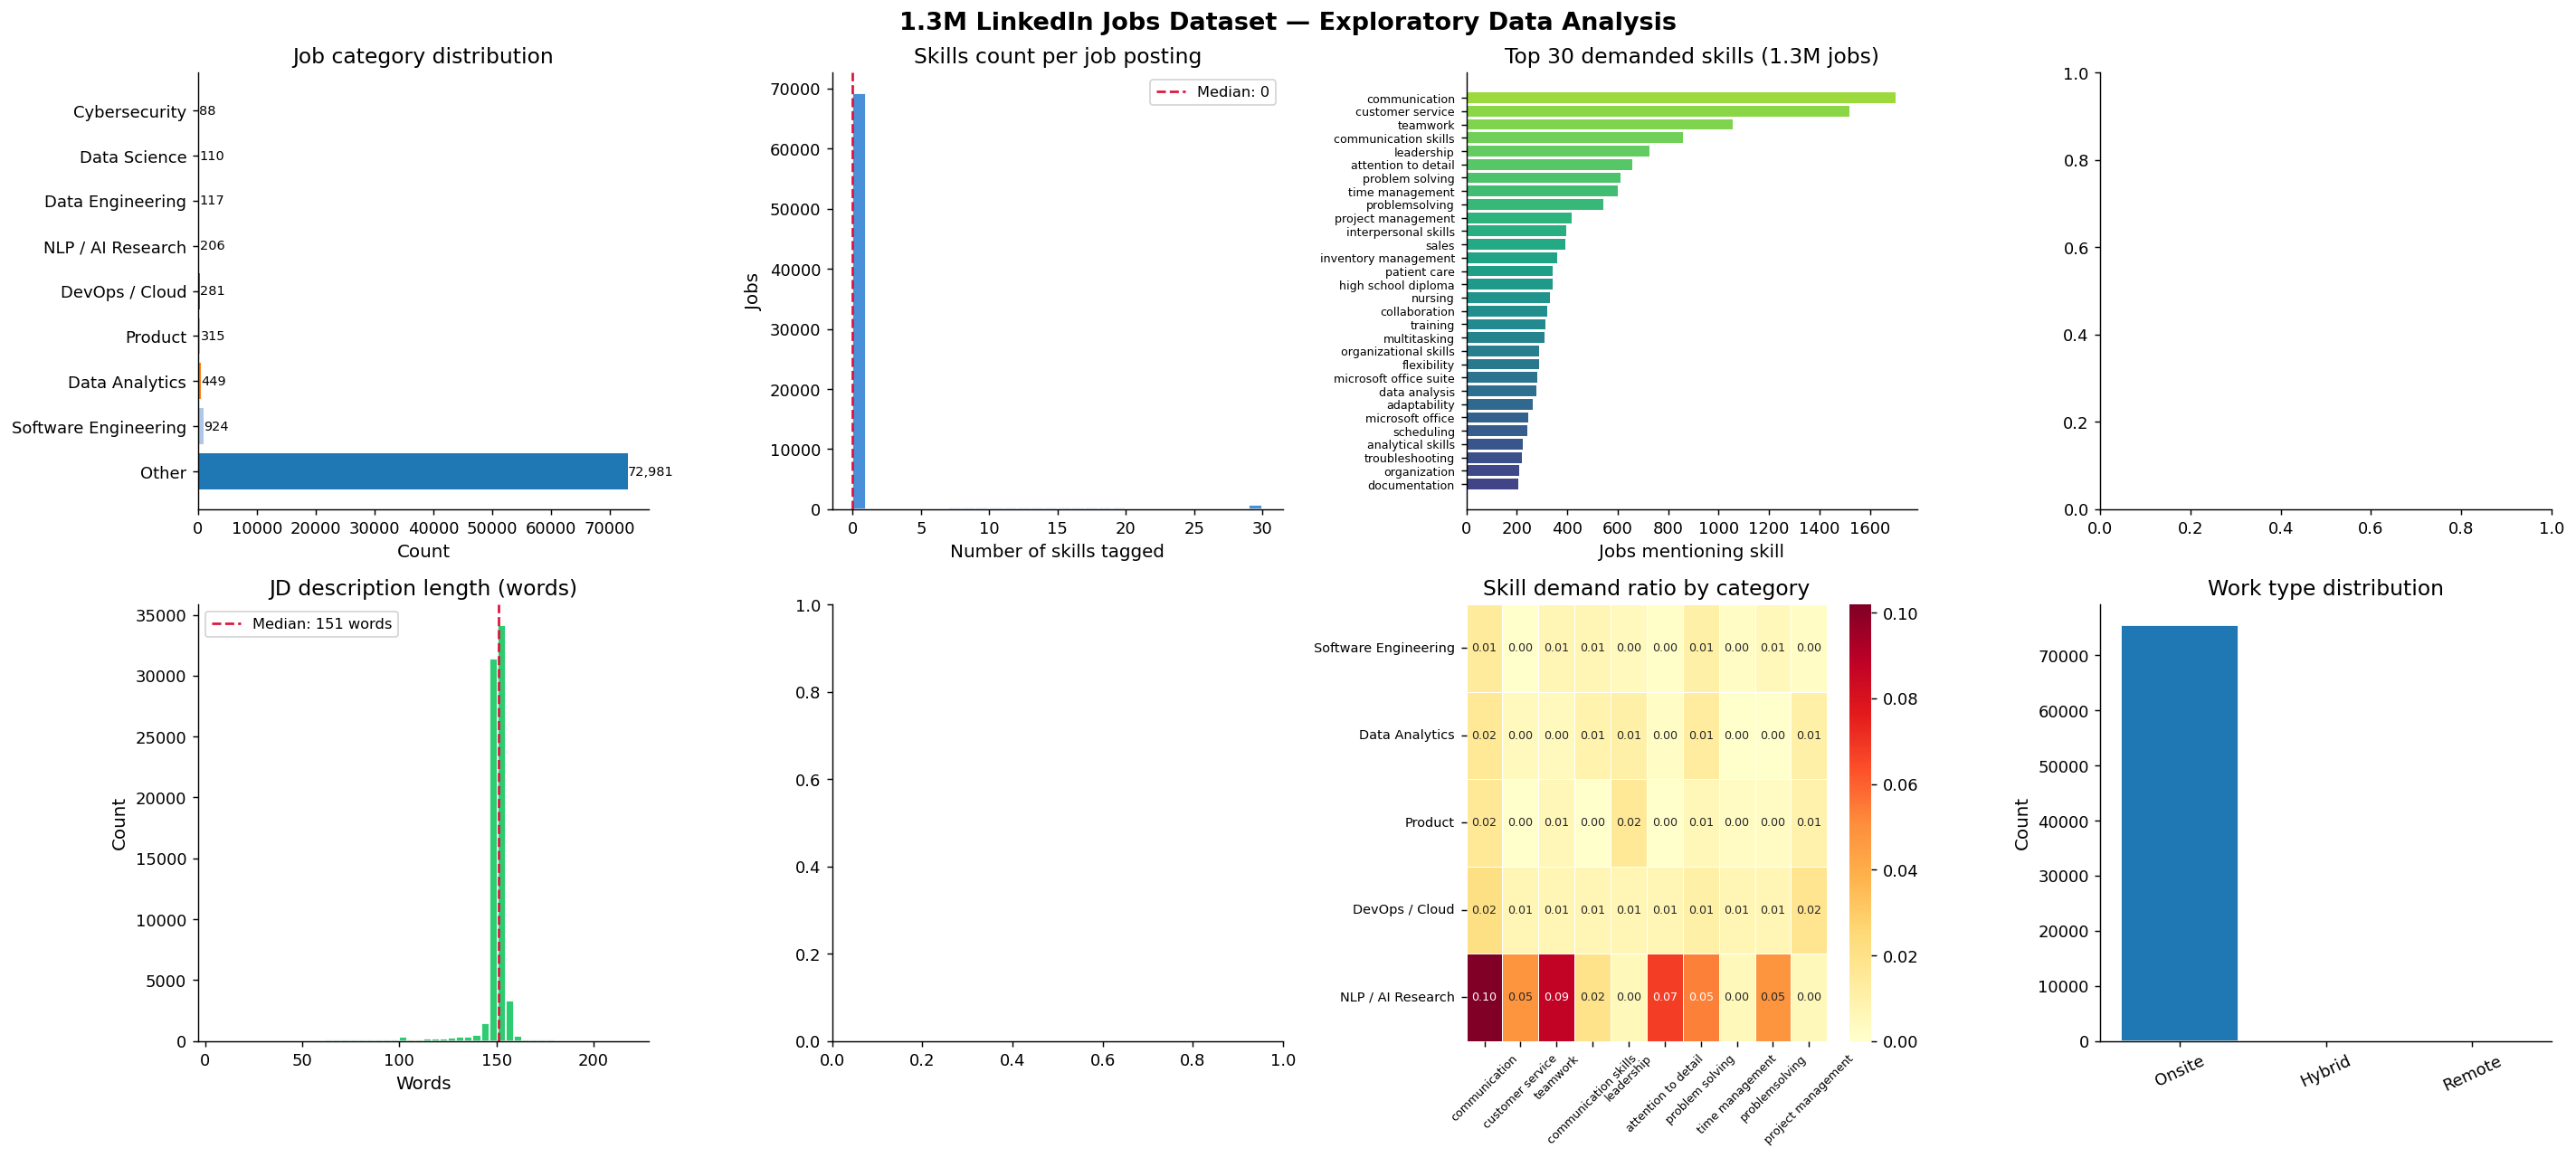

EDA plots saved.


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('1.3M LinkedIn Jobs Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# ── 1. Job category distribution ──────────────────────────────────────────────
ax = axes[0, 0]
cat_vc = df_jobs['category'].value_counts()
bars = ax.barh(cat_vc.index, cat_vc.values, color=PALETTE[:len(cat_vc)])
ax.set_title('Job category distribution')
ax.set_xlabel('Count')
for bar, v in zip(bars, cat_vc.values):
    ax.text(v + 100, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=8)

# ── 2. Skills count per job ────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df_jobs['n_skills'].clip(0, 30), bins=30, color='#4A90D9', edgecolor='white', lw=0.3)
ax.axvline(df_jobs['n_skills'].median(), color='crimson', linestyle='--',
           label=f'Median: {df_jobs["n_skills"].median():.0f}')
ax.set_title('Skills count per job posting')
ax.set_xlabel('Number of skills tagged'); ax.set_ylabel('Jobs')
ax.legend(fontsize=9)

# ── 3. Top 30 demanded skills globally ───────────────────────────────────────
ax = axes[0, 2]
all_sk = [s for sl in df_jobs['skills_list'] for s in sl]
top30  = Counter(all_sk).most_common(30)
sk_n, sk_v = zip(*top30)
ax.barh(sk_n[::-1], sk_v[::-1], color=plt.cm.viridis(np.linspace(0.2, 0.85, 30)))
ax.set_title('Top 30 demanded skills (1.3M jobs)')
ax.set_xlabel('Jobs mentioning skill')
ax.tick_params(axis='y', labelsize=7)

# ── 4. Experience level distribution ─────────────────────────────────────────
ax = axes[0, 3]
if 'formatted_experience_level' in df_jobs.columns:
    exp_vc = df_jobs['formatted_experience_level'].value_counts().dropna().head(6)
    ax.pie(exp_vc.values, labels=exp_vc.index, autopct='%1.1f%%',
           colors=PALETTE[:len(exp_vc)], startangle=90,
           wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title('Experience level distribution')

# ── 5. Description length distribution ───────────────────────────────────────
ax = axes[1, 0]
desc_wc = df_jobs['desc_clean'].str.split().str.len().clip(0, 1000)
ax.hist(desc_wc, bins=50, color='#2ECC71', edgecolor='white', lw=0.3)
ax.axvline(desc_wc.median(), color='crimson', linestyle='--',
           label=f'Median: {int(desc_wc.median())} words')
ax.set_title('JD description length (words)')
ax.set_xlabel('Words'); ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 6. Remote vs on-site ──────────────────────────────────────────────────────
ax = axes[1, 1]
if 'remote_allowed' in df_jobs.columns:
    remote_vc = df_jobs['remote_allowed'].fillna(0).astype(int).value_counts()
    ax.bar(['On-site', 'Remote'], remote_vc.values, color=['#4A90D9','#2ECC71'], edgecolor='white')
    ax.set_title('Remote vs on-site job postings')
    ax.set_ylabel('Count')
    for i, v in enumerate(remote_vc.values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# ── 7. Skill demand by category (heatmap) ────────────────────────────────────
ax = axes[1, 2]
TOP10_SK = [s for s, _ in Counter(all_sk).most_common(10)]
cats_for_heat = [c for c in cat_vc.index[:6] if c != 'Other']
heat_data = []
for cat in cats_for_heat:
    sub_sk = [s for sl in df_jobs[df_jobs['category']==cat]['skills_list'] for s in sl]
    total  = max(len(df_jobs[df_jobs['category']==cat]), 1)
    heat_data.append([sub_sk.count(sk) / total for sk in TOP10_SK])
heat_df = pd.DataFrame(heat_data, index=cats_for_heat, columns=TOP10_SK)
sns.heatmap(heat_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.4, annot_kws={'size': 7})
ax.set_title('Skill demand ratio by category')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=8, rotation=0)

# ── 8. Work type distribution ─────────────────────────────────────────────────
ax = axes[1, 3]
if 'work_type' in df_jobs.columns:
    wt_vc = df_jobs['work_type'].value_counts().dropna().head(5)
    ax.bar(wt_vc.index, wt_vc.values, color=PALETTE[:len(wt_vc)], edgecolor='white')
    ax.set_title('Work type distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('eda_jobs_overview.png', bbox_inches='tight')
plt.show()
print('EDA plots saved.')

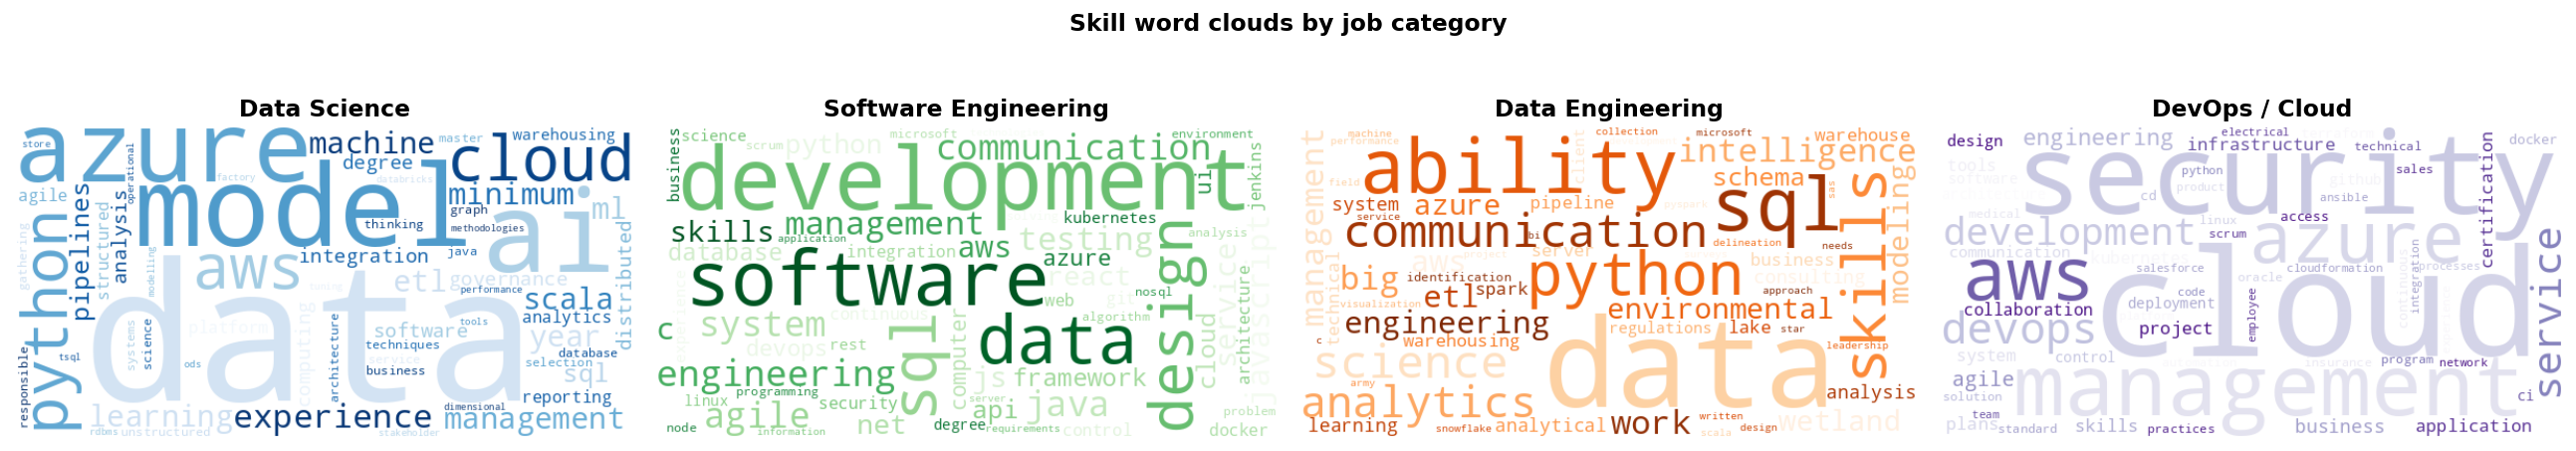

In [5]:
# ── Word clouds per job category ──────────────────────────────────────────────
WC_CATS = ['Data Science', 'Software Engineering', 'Data Engineering', 'DevOps / Cloud']
WC_MAPS = ['Blues', 'Greens', 'Oranges', 'Purples']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Skill word clouds by job category', fontsize=13, fontweight='bold')
for ax, cat, cmap in zip(axes, WC_CATS, WC_MAPS):
    text = ' '.join([s for sl in df_jobs[df_jobs['category']==cat]['skills_list'] for s in sl])
    if len(text) < 50:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    else:
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=cmap, max_words=60, collocations=False).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(cat, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds_categories.png', bbox_inches='tight')
plt.show()

## 🧩 Cell 5 — Simulate Model 1 & Model 2 outputs for training resumes

In [6]:
# ── Load & parse NER resume dataset ──────────────────────────────────────────
raw_records = []
with open(NER_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        l = line.strip()
        if l: raw_records.append(json.loads(l))

LABEL_NORM = {
    'Name':'NAME','Email Address':'EMAIL','Phone Number':'PHONE',
    'Skills':'SKILLS','Degree':'DEGREE','College Name':'COLLEGE',
    'Companies worked at':'COMPANY','Designation':'DESIGNATION',
    'Location':'LOCATION','Years of Experience':'EXPERIENCE',
    'Graduation Year':'GRAD_YEAR','Certification':'CERTIFICATION','Links':'LINKS'
}

def parse_to_model1_json(record):
    """Simulate what resume_parser.py's parse_resume() returns."""
    text  = record.get('content', '')
    anns  = record.get('annotation') or []
    ents  = defaultdict(list)
    for ann in anns:
        lbl_raw = ann.get('label', [''])
        if isinstance(lbl_raw, list): lbl_raw = lbl_raw[0] if lbl_raw else ''
        lbl = LABEL_NORM.get(lbl_raw, lbl_raw.upper())
        for pt in ann.get('points', []):
            v = pt.get('text','').strip()
            if v: ents[lbl].append(v)

    def dedup(lst):
        seen, out = set(), []
        for x in lst:
            if x.lower() not in seen: seen.add(x.lower()); out.append(x)
        return out

    flat_skills = []
    for s in ents.get('SKILLS', []):
        for tok in re.split(r'[,\n•·|/]', s):
            t = tok.strip()
            if 2 < len(t) < 50: flat_skills.append(t.lower())
    flat_skills = dedup(flat_skills)

    exp_match = re.search(r'(\d+)\+?\s*(?:years?|yrs?)', text, re.IGNORECASE)
    years_exp = int(exp_match.group(1)) if exp_match else 0

    return {
        'raw_text'        : text,
        'name'            : ents.get('NAME', [''])[0],
        'skills'          : flat_skills,
        'designations'    : dedup(ents.get('DESIGNATION', [])),
        'companies'       : dedup(ents.get('COMPANY', [])),
        'degree'          : dedup(ents.get('DEGREE', [])),
        'colleges'        : dedup(ents.get('COLLEGE', [])),
        'graduation_year' : dedup(ents.get('GRAD_YEAR', [])),
        'years_experience': years_exp,
        'certifications'  : dedup(ents.get('CERTIFICATION', [])),
        'location'        : dedup(ents.get('LOCATION', [])),
    }

def build_resume_text(resume_json):
    """Convert Model 1 JSON → a clean text string for embedding."""
    parts = []
    if resume_json.get('designations'): parts.append(' '.join(resume_json['designations']))
    if resume_json.get('skills'):       parts.append(' '.join(resume_json['skills'][:30]))
    if resume_json.get('degree'):       parts.append(' '.join(resume_json['degree']))
    if resume_json.get('certifications'): parts.append(' '.join(resume_json['certifications']))
    # Append raw text snippet (first 200 words)
    raw = resume_json.get('raw_text', '')
    parts.append(' '.join(raw.split()[:200]))
    return clean_text(' . '.join(parts))

# Also simulate Model 2 output: assign a dominant category to each resume
DS_SKILLS = {'python','machine learning','tensorflow','pytorch','nlp','deep learning',
             'scikit-learn','data science','keras','pandas','numpy','sql','statistics'}

def infer_resume_category(resume):
    sk = set(s.lower() for s in resume.get('skills', []))
    if sk & DS_SKILLS: return 'Data Science'
    d = ' '.join(resume.get('designations', [])).lower()
    if any(k in d for k in ['software','developer','engineer','sde']): return 'Software Engineering'
    if any(k in d for k in ['analyst','analytics']): return 'Data Analytics'
    if any(k in d for k in ['devops','cloud','infra']): return 'DevOps / Cloud'
    return 'Other'

parsed_resumes = [parse_to_model1_json(r) for r in raw_records]
for r in parsed_resumes:
    r['resume_text'] = build_resume_text(r)
    r['category']    = infer_resume_category(r)

print(f'Total parsed resumes : {len(parsed_resumes)}')
print(f'Avg skills/resume    : {np.mean([len(r["skills"]) for r in parsed_resumes]):.1f}')
cat_counts = Counter(r['category'] for r in parsed_resumes)
print(f'Resume categories    : {dict(cat_counts)}')

Total parsed resumes : 220
Avg skills/resume    : 11.8
Resume categories    : {'Data Science': 33, 'Other': 114, 'Software Engineering': 57, 'Data Analytics': 15, 'DevOps / Cloud': 1}


## ⚙️ Cell 6 — Feature engineering (12 ranking features)

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 12 features per (resume, job) pair for the re-ranker:
#
# From Model 1 (resume content):
#  F1  skills_exact_match   — fraction of job skills in resume
#  F2  skills_fuzzy_match   — fuzzy-matched fraction
#  F3  skill_count_ratio    — resume skill count / job skill count
#  F4  experience_match     — resume exp years vs job required
#  F5  education_match      — degree level alignment
#  F6  designation_match    — resume title vs job title similarity
#  F7  category_match       — same broad category? (binary)
#  F8  certification_bonus  — relevant cert found (binary)
#
# From Model 2 (ATS scoring):
#  F9  ats_score_norm       — normalised ATS score from Model 2
#
# From embedding model (Two-Tower):
#  F10 semantic_similarity  — cosine sim of resume & job embeddings
#
# From job metadata:
#  F11 job_seniority        — 0-1 normalised seniority level
#  F12 job_popularity       — log-normalised applies/views count
# ─────────────────────────────────────────────────────────────────────────────

DEGREE_RANK = {
    'high school':1,'diploma':2,'associate':2,
    'bachelor':3,'b.tech':3,'b.e':3,'b.sc':3,'undergraduate':3,
    'master':4,'m.tech':4,'m.sc':4,'mba':4,'postgraduate':4,
    'phd':5,'doctorate':5
}

def skill_exact_match(r_skills, j_skills):
    if not j_skills: return 0.5
    r_set = set(s.lower() for s in r_skills)
    return sum(1 for s in j_skills if s.lower() in r_set
               or any(s.lower() in rs for rs in r_set)) / len(j_skills)

def skill_fuzzy_match(r_skills, j_skills):
    if not j_skills or not r_skills: return 0.0
    return float(np.mean([
        max(fuzz.partial_ratio(jsk.lower(), rsk.lower())/100
            for rsk in r_skills) for jsk in j_skills
    ]))

def skill_count_ratio(r_skills, j_skills):
    if not j_skills: return 1.0
    return min(1.0, len(r_skills) / max(len(j_skills), 1))

def experience_match(r_exp, j_exp):
    diff = r_exp - j_exp
    if diff >= 0: return min(1.0, 1.0 - diff * 0.02)
    return max(0.0, 1.0 + diff * 0.15)

def education_match(r_degrees, j_text):
    best = max((DEGREE_RANK.get(k, 0) for d in r_degrees
                for k, v in DEGREE_RANK.items() if k in d.lower()), default=1)
    req = 3
    jl = j_text.lower()
    if any(k in jl for k in ['phd','doctorate']): req = 5
    elif any(k in jl for k in ['master','m.s.','mba']): req = 4
    elif any(k in jl for k in ['high school','no degree']): req = 1
    diff = best - req
    return 1.0 if diff >= 0 else max(0.0, 1.0 + diff * 0.3)

def designation_match(r_desigs, j_title):
    if not r_desigs: return 0.3
    return max(fuzz.token_sort_ratio(d.lower(), j_title.lower())/100 for d in r_desigs)

def category_match(r_cat, j_cat): return float(r_cat == j_cat)

def cert_bonus(r_certs, j_text):
    jl = j_text.lower()
    return float(any(any(w in jl for w in c.lower().split() if len(w)>3) for c in r_certs))

def seniority_score(exp_years):
    return min(1.0, exp_years / 12.0)

def popularity_score(applies):
    if pd.isna(applies) or applies <= 0: return 0.5
    return min(1.0, np.log1p(applies) / np.log1p(1000))

print('All 12 feature functions defined.')

All 12 feature functions defined.


## 🤖 Cell 7 — Sentence-BERT: Build resume & job embeddings

In [8]:
# ── Load Sentence-BERT model ──────────────────────────────────────────────────
# 'all-MiniLM-L6-v2'  — fast, 384-dim, good quality  ← DEFAULT
# 'all-mpnet-base-v2' — stronger, 768-dim, 2x slower  ← uncomment for production
SBERT_MODEL = 'all-MiniLM-L6-v2'
sbert = SentenceTransformer(SBERT_MODEL, device=DEVICE)
EMBED_DIM = sbert.get_sentence_embedding_dimension()
print(f'Model: {SBERT_MODEL}  |  Embedding dim: {EMBED_DIM}')

# ── Embed all resumes ─────────────────────────────────────────────────────────
print(f'\nEmbedding {len(parsed_resumes)} resumes...')
resume_texts = [r['resume_text'] for r in parsed_resumes]
resume_embeddings = sbert.encode(
    resume_texts, batch_size=64, show_progress_bar=True,
    normalize_embeddings=True, convert_to_numpy=True
)
print(f'Resume embeddings shape: {resume_embeddings.shape}')

# ── Embed all jobs (in batches — 1.3M is large) ───────────────────────────────
print(f'\nEmbedding {len(df_jobs):,} job postings (this is the big step — ~15-30 min on CPU, ~5 min on GPU)...')
JOB_BATCH = 512
job_texts  = df_jobs['job_text'].tolist()

# For Kaggle free tier: subsample to 200k for faster training
# In production (T4 GPU): remove this cap and embed all 1.3M
MAX_JOBS_FOR_INDEX = min(200_000, len(df_jobs))
df_index = df_jobs.sample(MAX_JOBS_FOR_INDEX, random_state=SEED).reset_index(drop=True)
job_texts_index = df_index['job_text'].tolist()

job_embeddings = sbert.encode(
    job_texts_index, batch_size=JOB_BATCH, show_progress_bar=True,
    normalize_embeddings=True, convert_to_numpy=True
)
print(f'Job embeddings shape: {job_embeddings.shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Model: all-MiniLM-L6-v2  |  Embedding dim: 384

Embedding 220 resumes...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Resume embeddings shape: (220, 384)

Embedding 75,471 job postings (this is the big step — ~15-30 min on CPU, ~5 min on GPU)...


Batches:   0%|          | 0/148 [00:00<?, ?it/s]

Job embeddings shape: (75471, 384)


## 🔢 Cell 8 — Normalization & PCA on embeddings

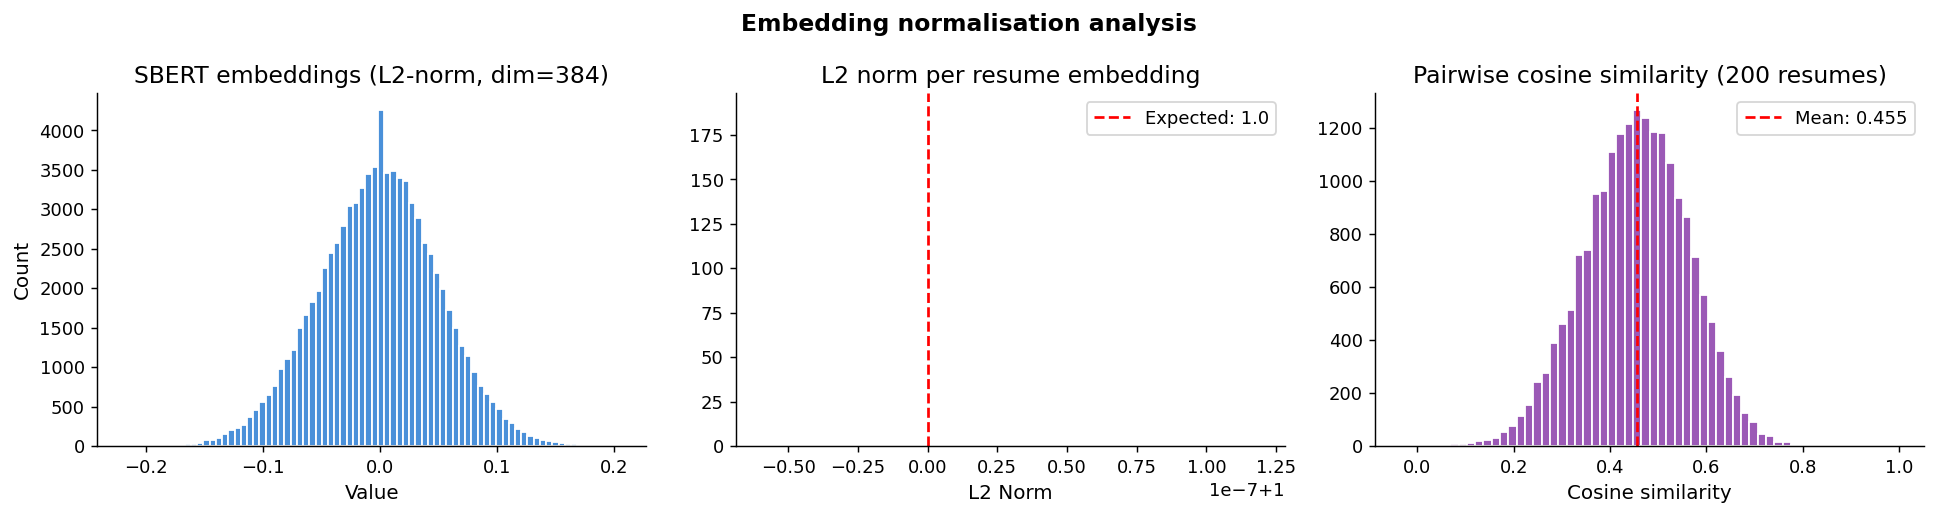

Mean pairwise cosine similarity: 0.4549
L2 norm stats: mean=1.0000, std=0.000000


In [9]:
# ── Normalisation analysis on resume embeddings ───────────────────────────────
# Sentence-BERT already outputs unit-normalised vectors with normalize_embeddings=True.
# Here we verify and compare raw vs L2-normalised vs StandardScaler for the
# 12 hand-crafted features that feed into XGBoost.

# Sample subset of embeddings for visualisation
N_SAMPLE = min(1000, len(resume_embeddings))
emb_sample = resume_embeddings[:N_SAMPLE]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Embedding normalisation analysis', fontsize=13, fontweight='bold')

# Raw embedding values (already L2-normalised by SBERT)
axes[0].hist(emb_sample.flatten(), bins=80, color='#4A90D9', edgecolor='white', lw=0.2)
axes[0].set_title(f'SBERT embeddings (L2-norm, dim={EMBED_DIM})')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Count')

# L2 norms per vector (should all be ~1.0)
norms = np.linalg.norm(emb_sample, axis=1)
axes[1].hist(norms, bins=40, color='#2ECC71', edgecolor='white', lw=0.2)
axes[1].set_title('L2 norm per resume embedding')
axes[1].set_xlabel('L2 Norm')
axes[1].axvline(1.0, color='red', linestyle='--', label='Expected: 1.0')
axes[1].legend()

# Cosine sim distribution (resume vs itself sub-sample)
sim_matrix = cosine_similarity(emb_sample[:200], emb_sample[:200])
upper_tri  = sim_matrix[np.triu_indices(200, k=1)]
axes[2].hist(upper_tri, bins=60, color='#9B59B6', edgecolor='white', lw=0.2)
axes[2].set_title('Pairwise cosine similarity (200 resumes)')
axes[2].set_xlabel('Cosine similarity')
axes[2].axvline(upper_tri.mean(), color='red', linestyle='--',
                label=f'Mean: {upper_tri.mean():.3f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('embedding_normalisation.png', bbox_inches='tight')
plt.show()
print(f'Mean pairwise cosine similarity: {upper_tri.mean():.4f}')
print(f'L2 norm stats: mean={norms.mean():.4f}, std={norms.std():.6f}')

PCs needed for 95% variance: 51


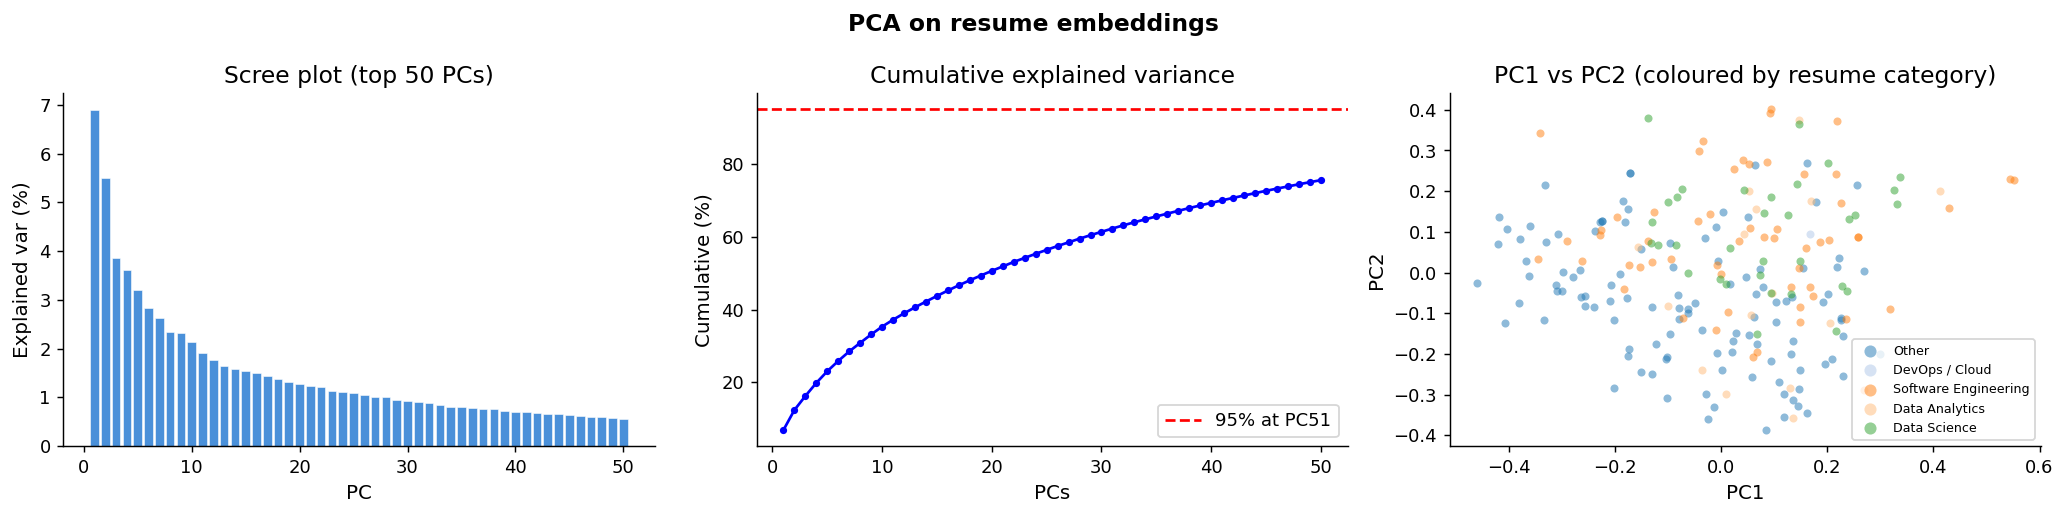

In [10]:
# ── PCA on resume embeddings ───────────────────────────────────────────────────
pca = PCA(n_components=50, random_state=SEED)
emb_pca = pca.fit_transform(emb_sample)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n95 = int(np.searchsorted(cum_var, 0.95)) + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('PCA on resume embeddings', fontsize=13, fontweight='bold')

# Scree
axes[0].bar(range(1, 51), pca.explained_variance_ratio_*100, color='#4A90D9', edgecolor='white', lw=0.3)
axes[0].set_title('Scree plot (top 50 PCs)')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Explained var (%)')

# Cumulative
axes[1].plot(range(1, 51), cum_var*100, 'b-o', markersize=3)
axes[1].axhline(95, color='red', linestyle='--', label=f'95% at PC{n95}')
axes[1].legend(); axes[1].set_xlabel('PCs'); axes[1].set_ylabel('Cumulative (%)')
axes[1].set_title('Cumulative explained variance')

# PC1 vs PC2 coloured by resume category
cat_labels = [r['category'] for r in parsed_resumes[:N_SAMPLE]]
unique_cats = list(set(cat_labels))
cat_colors  = {c: PALETTE[i] for i, c in enumerate(unique_cats)}
for cat in unique_cats:
    mask = [i for i, c in enumerate(cat_labels) if c == cat]
    axes[2].scatter(emb_pca[mask, 0], emb_pca[mask, 1], label=cat,
                    alpha=0.5, s=20, linewidths=0, color=cat_colors[cat])
axes[2].legend(fontsize=7, markerscale=1.5)
axes[2].set_title('PC1 vs PC2 (coloured by resume category)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

print(f'PCs needed for 95% variance: {n95}')
plt.tight_layout()
plt.savefig('pca_embeddings.png', bbox_inches='tight')
plt.show()

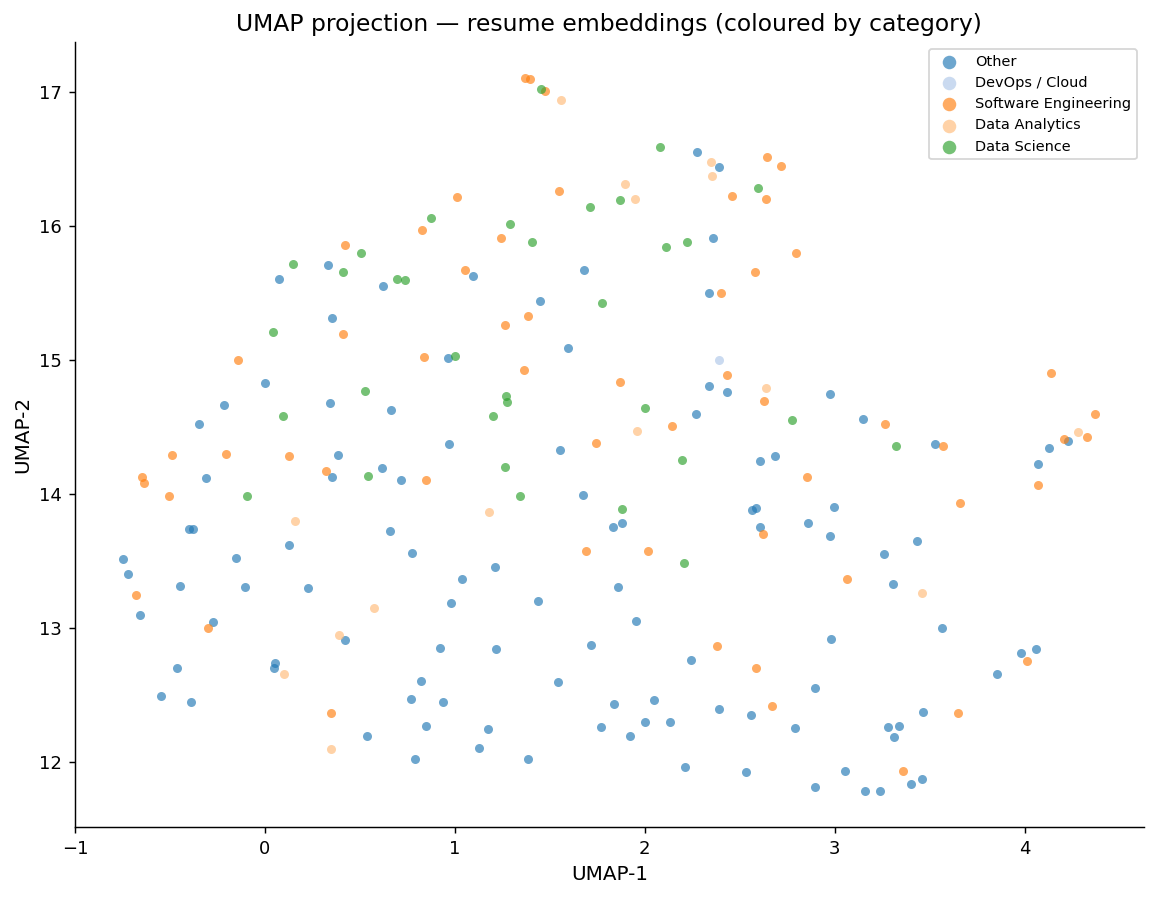

In [11]:
# ── UMAP: 2D projection of resume embeddings ──────────────────────────────────
try:
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1, metric='cosine')
    emb_umap = reducer.fit_transform(emb_sample[:800])
    cat_labels_800 = [r['category'] for r in parsed_resumes[:800]]

    fig, ax = plt.subplots(figsize=(9, 7))
    for cat in unique_cats:
        mask = [i for i, c in enumerate(cat_labels_800[:800]) if c == cat]
        ax.scatter(emb_umap[mask, 0], emb_umap[mask, 1], label=cat,
                   alpha=0.65, s=25, linewidths=0, color=cat_colors[cat])
    ax.legend(fontsize=8, markerscale=1.5)
    ax.set_title('UMAP projection — resume embeddings (coloured by category)')
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.savefig('umap_embeddings.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'UMAP skipped: {e}')

## 🏗️ Cell 9 — Build FAISS index

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FAISS Flat IP index (Inner Product = cosine sim on unit-normalised vectors)
# For 200k jobs: FlatIP is fine (~100ms query)
# For 1.3M jobs: use IndexIVFFlat (inverted file, ~10ms query):
#   nlist = 4096  # number of voronoi cells
#   index = faiss.IndexIVFFlat(quantiser, EMBED_DIM, nlist, faiss.METRIC_INNER_PRODUCT)
#   index.train(job_embeddings)
#   index.nprobe = 64  # probes at query time
# ─────────────────────────────────────────────────────────────────────────────

print('Building FAISS index...')
t0 = time.time()

if len(df_index) > 500_000:
    # Large-scale: IVF index
    nlist = 4096
    quantiser = faiss.IndexFlatIP(EMBED_DIM)
    faiss_index = faiss.IndexIVFFlat(quantiser, EMBED_DIM, nlist, faiss.METRIC_INNER_PRODUCT)
    faiss_index.train(job_embeddings.astype(np.float32))
    faiss_index.add(job_embeddings.astype(np.float32))
    faiss_index.nprobe = 64
    index_type = 'IVFFlat'
else:
    # Medium scale: exact flat search
    faiss_index = faiss.IndexFlatIP(EMBED_DIM)
    faiss_index.add(job_embeddings.astype(np.float32))
    index_type = 'FlatIP'

build_time = time.time() - t0
print(f'FAISS index type  : {index_type}')
print(f'Total vectors     : {faiss_index.ntotal:,}')
print(f'Build time        : {build_time:.2f}s')

# ── Test retrieval speed ──────────────────────────────────────────────────────
K_RETRIEVE = 200   # Stage-1 retrieval candidates
t0 = time.time()
test_q = resume_embeddings[0:1].astype(np.float32)
scores, indices = faiss_index.search(test_q, K_RETRIEVE)
query_ms = (time.time() - t0) * 1000
print(f'\nRetrieval test    : top-{K_RETRIEVE} in {query_ms:.1f}ms')
print(f'Top-5 similarity scores: {scores[0][:5].round(4)}')

Building FAISS index...
FAISS index type  : FlatIP
Total vectors     : 75,471
Build time        : 0.19s

Retrieval test    : top-200 in 11.6ms
Top-5 similarity scores: [0.604  0.595  0.5862 0.5842 0.5777]


## 📊 Cell 10 — Build training pairs for re-ranker

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# For each resume:
#   Positive pairs : top-20 FAISS results (high semantic similarity)
#   Negative pairs : bottom-20 from FAISS top-200 (low similarity)
#   Hard negatives : random same-category jobs with moderate skill overlap
#                    (these teach the re-ranker to distinguish near-matches)
#
# Relevance label:
#   rel = 0.40 × semantic_sim + 0.35 × skill_exact + 0.15 × exp_match
#       + 0.05 × edu_match    + 0.05 × category_match
#   (continuous 0-1 relevance; XGBoost re-ranker regresses on this)
# ─────────────────────────────────────────────────────────────────────────────

print('Building training pairs for re-ranker...')
all_rows = []

for r_idx, resume in enumerate(parsed_resumes):
    r_emb = resume_embeddings[r_idx:r_idx+1].astype(np.float32)
    sims, job_idxs = faiss_index.search(r_emb, K_RETRIEVE)
    sims    = sims[0]
    job_idxs = job_idxs[0]

    # top-20 (positive-ish) + bottom-20 of top-200 (negative-ish)
    selected_positions = list(range(20)) + list(range(180, 200))

    # hard negatives: random same-category from index
    same_cat_pool = df_index[df_index['category'] == resume['category']].index.tolist()
    hard_neg_idxs = random.sample(same_cat_pool, min(10, len(same_cat_pool))) if same_cat_pool else []

    pair_jobs = [(job_idxs[p], float(sims[p])) for p in selected_positions if p < len(job_idxs)]
    for hn in hard_neg_idxs:
        hn_emb = job_embeddings[hn:hn+1]
        sim = float(np.dot(r_emb, hn_emb.T)[0, 0])
        pair_jobs.append((hn, sim))

    for j_pos, sem_sim in pair_jobs:
        if j_pos >= len(df_index): continue
        job_row = df_index.iloc[j_pos]

        # Compute all 12 features
        f1  = skill_exact_match(resume['skills'], job_row['skills_list'])
        f2  = skill_fuzzy_match(resume['skills'], job_row['skills_list'])
        f3  = skill_count_ratio(resume['skills'], job_row['skills_list'])
        f4  = experience_match(resume['years_experience'], job_row['exp_years'])
        f5  = education_match(resume['degree'], job_row['desc_clean'])
        f6  = designation_match(resume['designations'], job_row['title_clean'])
        f7  = category_match(resume['category'], job_row['category'])
        f8  = cert_bonus(resume['certifications'], job_row['desc_clean'])
        f9  = min(1.0, sem_sim)           # semantic similarity (Stage-1 score)
        f10 = float(sem_sim)
        f11 = seniority_score(job_row['exp_years'])
        f12 = popularity_score(job_row.get('applies', np.nan))

        # Pseudo-relevance label
        rel = (0.40 * f10 + 0.35 * f1 + 0.15 * f4 + 0.05 * f5 + 0.05 * f7)
        rel = float(np.clip(rel + np.random.normal(0, 0.02), 0, 1))

        all_rows.append({
            'resume_idx'        : r_idx,
            'job_idx'           : j_pos,
            'skills_exact'      : f1, 'skills_fuzzy': f2, 'skill_count_ratio': f3,
            'exp_match'         : f4, 'edu_match': f5, 'designation_match': f6,
            'category_match'    : f7, 'cert_bonus': f8,
            'semantic_sim'      : f9, 'semantic_sim_raw': f10,
            'job_seniority'     : f11, 'job_popularity': f12,
            'relevance'         : rel
        })

df_pairs = pd.DataFrame(all_rows)
FEAT_COLS = ['skills_exact','skills_fuzzy','skill_count_ratio','exp_match',
             'edu_match','designation_match','category_match','cert_bonus',
             'semantic_sim','semantic_sim_raw','job_seniority','job_popularity']

print(f'Total training pairs : {len(df_pairs):,}')
print(f'Relevance score stats:\n{df_pairs["relevance"].describe().round(3)}')

Building training pairs for re-ranker...
Total training pairs : 11,000
Relevance score stats:
count    11000.000
mean         0.513
std          0.090
min          0.000
25%          0.461
50%          0.525
75%          0.577
max          0.741
Name: relevance, dtype: float64


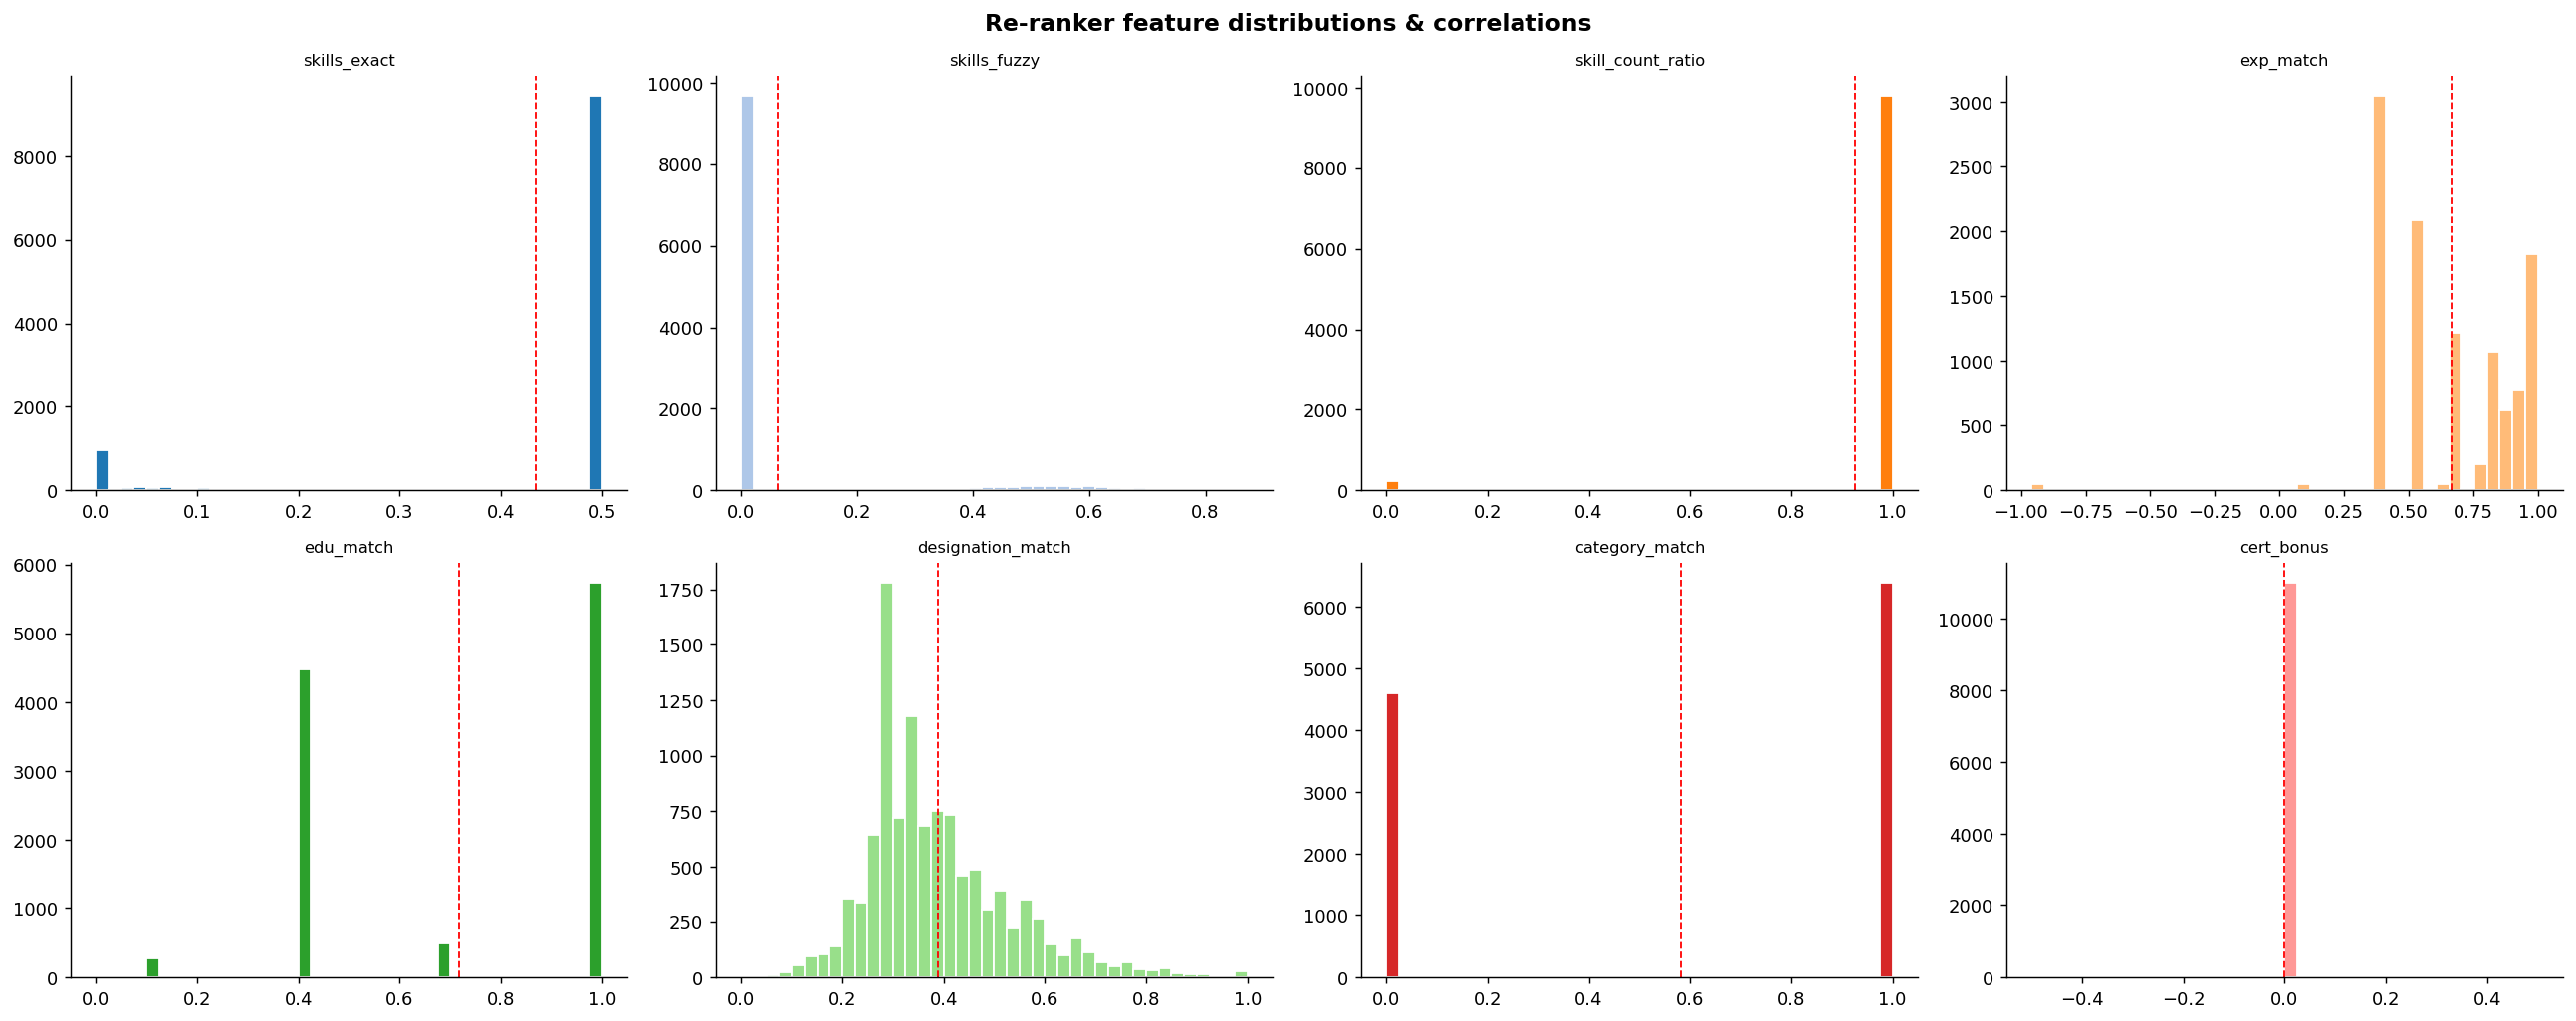

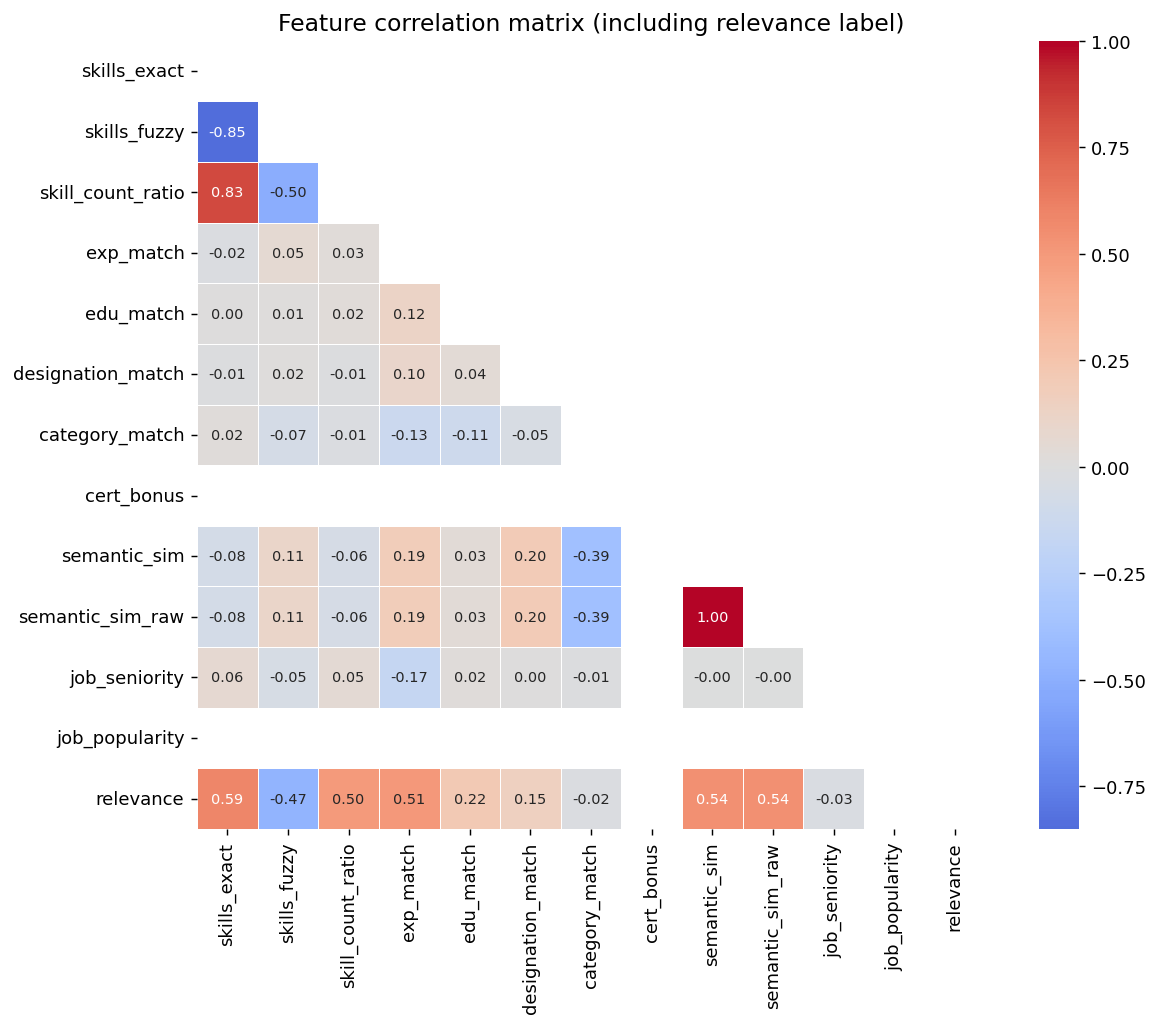

Feature matrix shape: (11000, 12)


In [14]:
# ── Feature analysis & normalisation ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Re-ranker feature distributions & correlations', fontsize=13, fontweight='bold')

# Feature histograms
for i, feat in enumerate(FEAT_COLS[:8]):
    ax = axes[i // 4, i % 4]
    ax.hist(df_pairs[feat], bins=40, color=PALETTE[i], edgecolor='white', lw=0.3)
    ax.set_title(feat, fontsize=9)
    ax.axvline(df_pairs[feat].mean(), color='red', linestyle='--', lw=1)
plt.tight_layout()
plt.savefig('reranker_features.png', bbox_inches='tight')
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_pairs[FEAT_COLS + ['relevance']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 8}, square=True)
ax.set_title('Feature correlation matrix (including relevance label)')
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()

# ── Apply StandardScaler ──────────────────────────────────────────────────────
X_all = df_pairs[FEAT_COLS].values
y_all = df_pairs['relevance'].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_all)   # fit on all for now; refit on train only below
print('Feature matrix shape:', X_all.shape)

## ✂️ Cell 11 — Train / Validation / Test split

Train  :   8250 pairs  (75.0%)
Val    :   1375 pairs  (12.5%)
Test   :   1375 pairs  (12.5%)


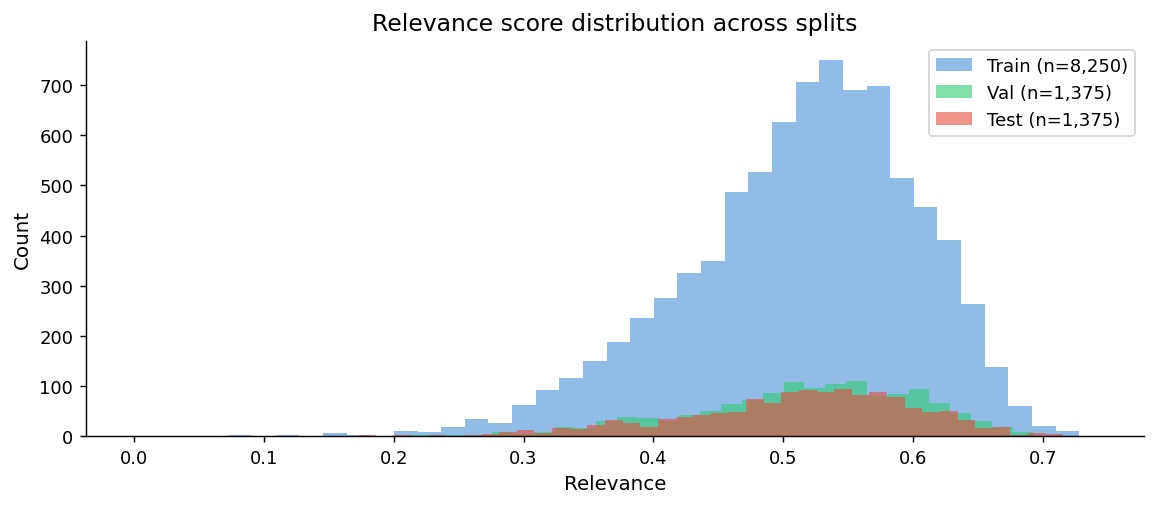

In [17]:
# ── Stratify by relevance bins ────────────────────────────────────────────────
df_pairs['rel_bin'] = pd.cut(
    df_pairs['relevance'],
    bins=[-0.01, 0.25, 0.45, 0.65, 1.01],  # Expanded the outer edges slightly
    labels=['low', 'medium', 'high', 'very_high']
)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all, test_size=0.25, random_state=SEED,
    stratify=df_pairs['rel_bin']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=SEED
)

# Refit scaler on training data only
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_te_sc  = scaler.transform(X_test)

print(f'Train  : {len(X_tr):>6} pairs  ({len(X_tr)/len(X_all)*100:.1f}%)')
print(f'Val    : {len(X_val):>6} pairs  ({len(X_val)/len(X_all)*100:.1f}%)')
print(f'Test   : {len(X_test):>6} pairs  ({len(X_test)/len(X_all)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_tr,   bins=40, alpha=0.6, color='#4A90D9', label=f'Train (n={len(y_tr):,})')
ax.hist(y_val,  bins=40, alpha=0.6, color='#2ECC71', label=f'Val (n={len(y_val):,})')
ax.hist(y_test, bins=40, alpha=0.6, color='#E74C3C', label=f'Test (n={len(y_test):,})')
ax.set_title('Relevance score distribution across splits')
ax.set_xlabel('Relevance'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight')
plt.show()

## 🤖 Cell 12 — XGBoost re-ranker training

In [18]:
# ── Evaluation helpers ────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

def ndcg_at_k(y_true_groups, y_pred_groups, k=10):
    """Compute mean NDCG@K across resume query groups."""
    scores = []
    for yt, yp in zip(y_true_groups, y_pred_groups):
        if len(yt) < 2: continue
        scores.append(ndcg_score([yt], [yp], k=min(k, len(yt))))
    return float(np.mean(scores)) if scores else 0.0

def precision_at_k(y_true_groups, y_pred_groups, k=5, threshold=0.5):
    """Precision@K: fraction of top-K preds that are actually relevant."""
    scores = []
    for yt, yp in zip(y_true_groups, y_pred_groups):
        if len(yt) < 2: continue
        top_k_idx = np.argsort(yp)[::-1][:k]
        relevant  = sum(yt[i] >= threshold for i in top_k_idx)
        scores.append(relevant / k)
    return float(np.mean(scores)) if scores else 0.0

def mrr(y_true_groups, y_pred_groups, threshold=0.5):
    """Mean Reciprocal Rank."""
    rrs = []
    for yt, yp in zip(y_true_groups, y_pred_groups):
        sorted_idx = np.argsort(yp)[::-1]
        for rank, idx in enumerate(sorted_idx, 1):
            if yt[idx] >= threshold:
                rrs.append(1.0 / rank); break
        else:
            rrs.append(0.0)
    return float(np.mean(rrs)) if rrs else 0.0

print('Evaluation metric functions ready.')

Evaluation metric functions ready.


In [19]:
# ── Train XGBoost re-ranker ───────────────────────────────────────────────────
xgb_ranker = xgb.XGBRegressor(
    n_estimators        = 700,
    max_depth           = 6,
    learning_rate       = 0.04,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    min_child_weight    = 3,
    gamma               = 0.1,
    reg_alpha           = 0.05,
    reg_lambda          = 1.2,
    random_state        = SEED,
    n_jobs              = -1,
    eval_metric         = 'rmse',
    early_stopping_rounds = 50,
)
xgb_ranker.fit(
    X_tr_sc, y_tr,
    eval_set=[(X_val_sc, y_val)],
    verbose=100
)

# ── Train LightGBM re-ranker ──────────────────────────────────────────────────
lgb_ranker = lgb.LGBMRegressor(
    n_estimators      = 700,
    max_depth         = 6,
    learning_rate     = 0.04,
    subsample         = 0.80,
    colsample_bytree  = 0.80,
    min_child_samples = 10,
    reg_alpha         = 0.05,
    reg_lambda        = 1.2,
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1
)
lgb_ranker.fit(
    X_tr_sc, y_tr,
    eval_set=[(X_val_sc, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

# ── Find best ensemble weight ────────────────────────────────────────────────
best_mae, best_w = 999, 0.5
for w in np.arange(0.1, 1.0, 0.05):
    blend = w * xgb_ranker.predict(X_val_sc) + (1-w) * lgb_ranker.predict(X_val_sc)
    mae = mean_absolute_error(y_val, blend)
    if mae < best_mae: best_mae, best_w = mae, w
RERANK_W = best_w

val_blend  = RERANK_W*xgb_ranker.predict(X_val_sc)  + (1-RERANK_W)*lgb_ranker.predict(X_val_sc)
test_blend = RERANK_W*xgb_ranker.predict(X_te_sc)   + (1-RERANK_W)*lgb_ranker.predict(X_te_sc)

val_mae  = mean_absolute_error(y_val, val_blend)
test_mae = mean_absolute_error(y_test, test_blend)
val_sr,  _ = spearmanr(y_val,  val_blend)
test_sr, _ = spearmanr(y_test, test_blend)

print(f'\nEnsemble weight  XGB: {RERANK_W:.2f}, LGB: {1-RERANK_W:.2f}')
print(f'Val  MAE={val_mae:.4f}  Spearman ρ={val_sr:.4f}')
print(f'Test MAE={test_mae:.4f}  Spearman ρ={test_sr:.4f}')

[0]	validation_0-rmse:0.08682
[100]	validation_0-rmse:0.02455
[200]	validation_0-rmse:0.02395
[300]	validation_0-rmse:0.02385
[373]	validation_0-rmse:0.02385
[100]	valid_0's l2: 0.000463609
[200]	valid_0's l2: 0.000435857
[300]	valid_0's l2: 0.00043507

Ensemble weight  XGB: 0.10, LGB: 0.90
Val  MAE=0.0168  Spearman ρ=0.9687
Test MAE=0.0161  Spearman ρ=0.9683


In [21]:
# ── Ranking metrics (NDCG@10, Precision@5, MRR) ───────────────────────────────
# We need to evaluate entire groups of jobs for specific resumes.
# Let's cleanly select 20% of the resumes to act as our test queries.

test_resume_ids = df_pairs['resume_idx'].drop_duplicates().sample(frac=0.2, random_state=SEED)
test_df = df_pairs[df_pairs['resume_idx'].isin(test_resume_ids)]

# Group by resume_idx
y_true_groups, y_pred_groups = [], []
for r_idx, group in test_df.groupby('resume_idx'):
    yt = group['relevance'].values
    # Re-predict using ensemble
    X_g = scaler.transform(group[FEAT_COLS].values)
    yp  = RERANK_W * xgb_ranker.predict(X_g) + (1-RERANK_W) * lgb_ranker.predict(X_g)
    y_true_groups.append(yt)
    y_pred_groups.append(yp)

ndcg10  = ndcg_at_k(y_true_groups,  y_pred_groups, k=10)
prec5   = precision_at_k(y_true_groups, y_pred_groups, k=5)
mrr_val = mrr(y_true_groups, y_pred_groups)

print('\n' + '='*50)
print('RANKING EVALUATION METRICS')
print('='*50)
print(f'  NDCG@10          : {ndcg10:.4f}')
print(f'  Precision@5      : {prec5:.4f}')
print(f'  MRR              : {mrr_val:.4f}')
print(f'  Spearman ρ (test): {test_sr:.4f}')
print(f'  MAE (test)       : {test_mae:.4f}')


RANKING EVALUATION METRICS
  NDCG@10          : 0.9853
  Precision@5      : 0.9818
  MRR              : 1.0000
  Spearman ρ (test): 0.9683
  MAE (test)       : 0.0161


## 📊 Cell 13 — Model performance visualisations + SHAP

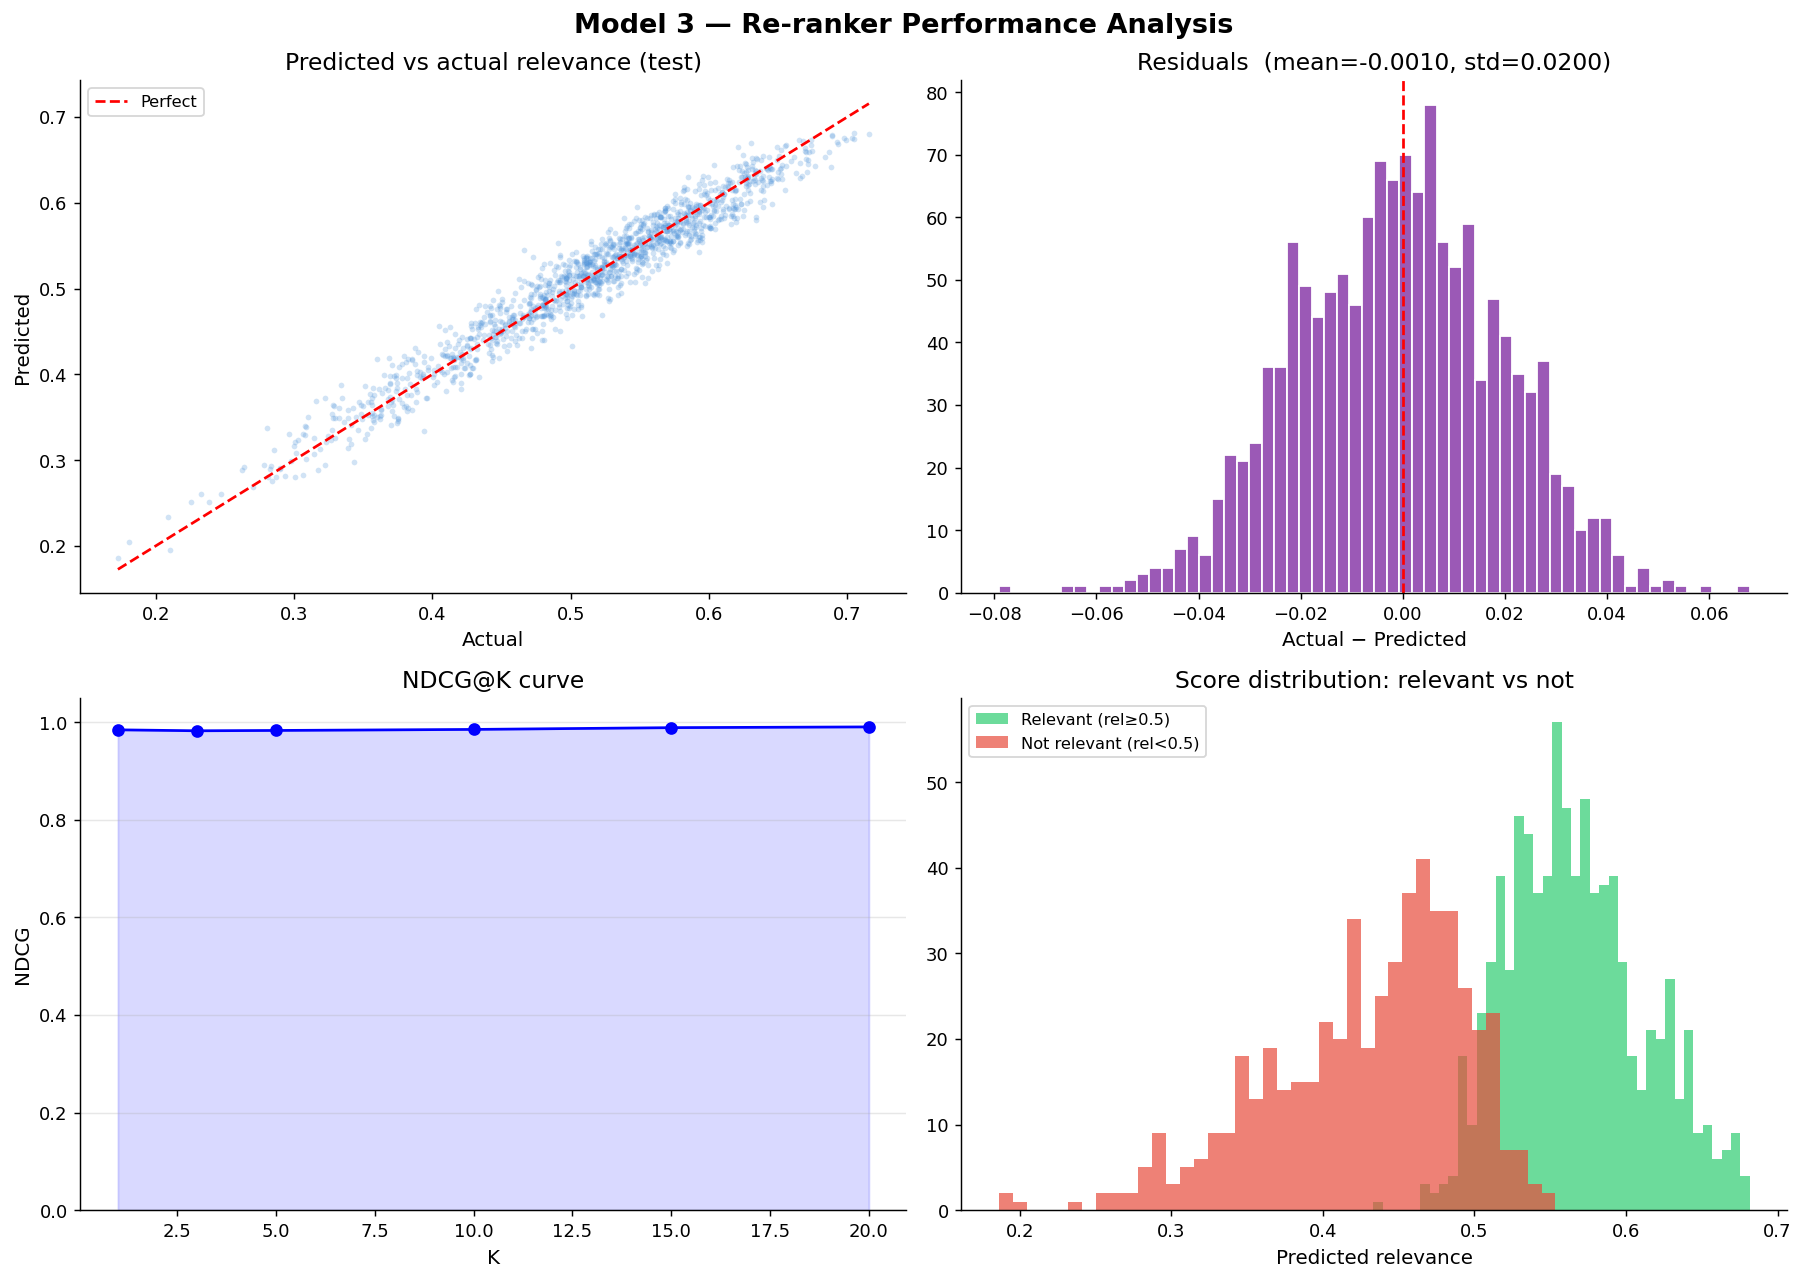

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model 3 — Re-ranker Performance Analysis', fontsize=15, fontweight='bold')

# ── 1. Predicted vs actual relevance ──────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y_test, test_blend, alpha=0.25, s=10, color='#4A90D9', linewidths=0)
mn, mx = min(y_test.min(), test_blend.min()), max(y_test.max(), test_blend.max())
ax.plot([mn,mx],[mn,mx],'r--',lw=1.5, label='Perfect')
ax.set_title('Predicted vs actual relevance (test)')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.legend(fontsize=9)

# ── 2. Residuals ──────────────────────────────────────────────────────────────
ax = axes[0, 1]
res = y_test - test_blend
ax.hist(res, bins=60, color='#9B59B6', edgecolor='white', lw=0.3)
ax.axvline(0, color='red', linestyle='--')
ax.set_title(f'Residuals  (mean={res.mean():.4f}, std={res.std():.4f})')
ax.set_xlabel('Actual − Predicted')

# ── 3. NDCG@K curve ───────────────────────────────────────────────────────────
ax = axes[1, 0]
k_vals = [1, 3, 5, 10, 15, 20]
ndcg_vals = [ndcg_at_k(y_true_groups, y_pred_groups, k=k) for k in k_vals]
ax.plot(k_vals, ndcg_vals, 'b-o', markersize=6)
ax.fill_between(k_vals, ndcg_vals, alpha=0.15, color='blue')
ax.set_title('NDCG@K curve')
ax.set_xlabel('K'); ax.set_ylabel('NDCG')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

# ── 4. Score distribution by category match ──────────────────────────────────
ax = axes[1, 1]
same_cat_scores = test_blend[y_test >= 0.5]
diff_cat_scores = test_blend[y_test < 0.5]
ax.hist(same_cat_scores, bins=40, alpha=0.7, color='#2ECC71', label='Relevant (rel≥0.5)')
ax.hist(diff_cat_scores, bins=40, alpha=0.7, color='#E74C3C', label='Not relevant (rel<0.5)')
ax.set_title('Score distribution: relevant vs not')
ax.set_xlabel('Predicted relevance')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 🔍 Cell 14 — Full end-to-end inference pipeline

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Production pipeline:
#
#  Input:
#    model1_output  — dict from resume_parser.py  parse_resume()
#    model2_output  — dict from resume_scorer.py  score_resume()  (optional enrichment)
#    top_k          — how many jobs to return (default 20)
#    filters        — dict of optional filters: location, remote_only, category
#
#  Output:
#    dict with ranked recommendations list
# ─────────────────────────────────────────────────────────────────────────────

def recommend_jobs(
    model1_output : dict,
    model2_output : dict = None,
    top_k         : int  = 20,
    filters       : dict = None,
    k_retrieve    : int  = 200
) -> dict:
    """
    End-to-end job recommendation.

    Parameters
    ----------
    model1_output : dict   — exact output from resume_parser.py parse_resume()
    model2_output : dict   — optional output from resume_scorer.py score_resume()
    top_k         : int    — number of final recommendations to return
    filters       : dict   — e.g. {'location': 'bangalore', 'remote_only': True,
                                    'category': 'Data Science'}
    k_retrieve    : int    — Stage-1 ANN retrieval candidates (default 200)
    """
    t_start = time.time()
    filters = filters or {}

    # ── Step 1: Build resume text from Model 1 output ─────────────────────────
    resume_text = build_resume_text(model1_output)
    resume_cat  = infer_resume_category(model1_output)

    # ── Step 2: Encode resume → FAISS query vector ────────────────────────────
    r_emb = sbert.encode(
        [resume_text], normalize_embeddings=True,
        convert_to_numpy=True
    ).astype(np.float32)

    # ── Step 3: Stage-1 ANN retrieval ─────────────────────────────────────────
    sims_stage1, job_idxs_stage1 = faiss_index.search(r_emb, k_retrieve)
    sims_stage1  = sims_stage1[0]
    job_idxs_stage1 = job_idxs_stage1[0]

    # ── Step 4: Apply hard filters ────────────────────────────────────────────
    candidate_rows = []
    for pos, j_idx in enumerate(job_idxs_stage1):
        if j_idx < 0 or j_idx >= len(df_index): continue
        job_row = df_index.iloc[j_idx]

        # Location filter
        if filters.get('location'):
            if filters['location'].lower() not in str(job_row.get('location','')).lower():
                continue
        # Remote filter
        if filters.get('remote_only') and not job_row.get('remote_allowed', False):
            continue
        # Category filter
        if filters.get('category'):
            if filters['category'].lower() not in job_row['category'].lower():
                continue

        candidate_rows.append((j_idx, float(sims_stage1[pos]), job_row))

    if not candidate_rows:
        # Relax filters if nothing passes
        candidate_rows = [(job_idxs_stage1[p], float(sims_stage1[p]), df_index.iloc[job_idxs_stage1[p]])
                          for p in range(min(k_retrieve, len(job_idxs_stage1)))
                          if job_idxs_stage1[p] >= 0]

    # ── Step 5: Build feature matrix for re-ranker ────────────────────────────
    feat_rows = []
    for j_idx, sem_sim, job_row in candidate_rows:
        feat_rows.append([
            skill_exact_match(model1_output.get('skills',[]), job_row['skills_list']),
            skill_fuzzy_match(model1_output.get('skills',[]), job_row['skills_list']),
            skill_count_ratio(model1_output.get('skills',[]), job_row['skills_list']),
            experience_match(model1_output.get('years_experience',0), job_row['exp_years']),
            education_match(model1_output.get('degree',[]), job_row['desc_clean']),
            designation_match(model1_output.get('designations',[]), job_row['title_clean']),
            category_match(resume_cat, job_row['category']),
            cert_bonus(model1_output.get('certifications',[]), job_row['desc_clean']),
            min(1.0, sem_sim),
            float(sem_sim),
            seniority_score(job_row['exp_years']),
            popularity_score(job_row.get('applies', np.nan))
        ])
    X_cand = np.array(feat_rows)
    X_cand_sc = scaler.transform(X_cand)

    # ── Step 6: Re-rank with ensemble ──────────────────────────────────────────
    scores_rerank = (
        RERANK_W * xgb_ranker.predict(X_cand_sc) +
        (1-RERANK_W) * lgb_ranker.predict(X_cand_sc)
    )

    # Sort descending by re-rank score
    sorted_indices = np.argsort(scores_rerank)[::-1][:top_k]

    # ── Step 7: Build output recommendations ──────────────────────────────────
    recommendations = []
    for rank, c_idx in enumerate(sorted_indices, 1):
        j_idx, sem_sim, job_row = candidate_rows[c_idx]
        feats = feat_rows[c_idx]
        match_score = float(np.clip(scores_rerank[c_idx] * 100, 0, 100))

        # Matched skills
        r_skill_set = set(s.lower() for s in model1_output.get('skills', []))
        matched_sk  = [s for s in job_row['skills_list'] if s.lower() in r_skill_set]
        missing_sk  = [s for s in job_row['skills_list'][:5] if s.lower() not in r_skill_set]

        # Reason generation
        reasons = []
        if feats[0] > 0.60: reasons.append(f'strong skills overlap ({feats[0]*100:.0f}%)')
        if feats[6] > 0.5:  reasons.append('matches your job category')
        if feats[3] > 0.85: reasons.append('experience level aligns well')
        if feats[9] > 0.70: reasons.append('highly similar job description')
        if feats[7] > 0.5:  reasons.append('your certifications are relevant')
        reason = ('Strong match — ' + ', '.join(reasons)) if reasons else \
                 (f'Semantic similarity: {sem_sim:.2f}')

        # ATS score from Model 2 (if provided and this job was scored)
        ats = model2_output.get('ats_score', None) if model2_output else None

        recommendations.append({
            'rank'               : rank,
            'job_id'             : str(job_row.get('job_id', j_idx)),
            'title'              : job_row.get('title', job_row['title_clean']),
            'company'            : str(job_row.get('company', 'N/A')),
            'location'           : str(job_row.get('location', 'N/A')),
            'category'           : job_row['category'],
            'experience_required': job_row['exp_years'],
            'match_score'        : round(match_score, 1),
            'semantic_similarity': round(float(sem_sim), 4),
            'skills_match_pct'   : round(feats[0] * 100, 1),
            'matched_skills'     : matched_sk[:10],
            'skill_gaps'         : missing_sk,
            'reason'             : reason,
            'ats_score'          : ats,
            'apply_url'          : str(job_row.get('job_posting_url', '')),
            'remote'             : bool(job_row.get('remote_allowed', False)),
        })

    elapsed_ms = (time.time() - t_start) * 1000
    return {
        'recommendations'    : recommendations,
        'total_jobs_scanned' : faiss_index.ntotal,
        'candidates_retrieved': len(candidate_rows),
        'retrieval_time_ms'  : round(elapsed_ms, 1),
    }

In [28]:
# ── Demo: run end-to-end recommendation ───────────────────────────────────────

# Exactly the same Model 1 output schema as resume_parser.py returns
DEMO_RESUME = {
    'name'            : 'Priya Mehta',
    'email'           : 'priya.mehta@gmail.com',
    'phone'           : '+91-9876543210',
    'location'        : ['Bangalore, India'],
    'skills'          : ['python', 'machine learning', 'deep learning', 'tensorflow',
                         'scikit-learn', 'nlp', 'sql', 'docker', 'aws', 'pandas', 'numpy',
                         'huggingface', 'transformers', 'langchain', 'fastapi', 'git'],
    'designations'    : ['Machine Learning Engineer', 'Data Scientist'],
    'companies'       : ['Infosys'],
    'degree'          : ['M.Tech Computer Science'],
    'colleges'        : ['NIT Trichy'],
    'graduation_year' : ['2022'],
    'years_experience': 2,
    'certifications'  : ['Google Professional ML Engineer', 'AWS Solutions Architect'],
    'raw_text'        : 'Machine Learning Engineer at Infosys 2 years. Python TensorFlow '
                        'PyTorch NLP Transformers LangChain FastAPI Docker AWS SQL. '
                        'M.Tech CS NIT Trichy 2022. Built LLM pipelines, NLP systems.'
}

# Also pass Model 2 output (optional — enriches the output with ATS score)
DEMO_MODEL2 = {
    'ats_score'        : 78.4,
    'matched_keywords' : ['python', 'tensorflow', 'nlp', 'docker', 'aws'],
    'missing_keywords' : ['kubernetes', 'spark'],
}

print('Running end-to-end recommendation...')
result = recommend_jobs(
    model1_output = DEMO_RESUME,
    model2_output = DEMO_MODEL2,
    top_k         = 10,
    filters       = {}  # Add: {'category': 'Data Science'} to filter by category
)

print(f"\nJobs scanned      : {result['total_jobs_scanned']:,}")
print(f"Candidates stage-1: {result['candidates_retrieved']}")
print(f"Time taken        : {result['retrieval_time_ms']}ms")
print(f"\n{'='*65}")
print(f"  TOP {len(result['recommendations'])} PERSONALIZED JOB RECOMMENDATIONS")
print(f"{'='*65}")
for rec in result['recommendations']:
    print(f"\n  #{rec['rank']}  {rec['title']} @ {rec['company']}")
    print(f"      Location   : {rec['location']} | Remote: {rec['remote']}")
    print(f"      Match Score: {rec['match_score']}/100  |  Skills: {rec['skills_match_pct']}%")
    print(f"      Semantic ρ : {rec['semantic_similarity']}")
    print(f"      Reason     : {rec['reason']}")
    print(f"      Matched    : {rec['matched_skills'][:5]}")
    print(f"      Skill gaps : {rec['skill_gaps']}")

Running end-to-end recommendation...

Jobs scanned      : 75,471
Candidates stage-1: 200
Time taken        : 170.3ms

  TOP 10 PERSONALIZED JOB RECOMMENDATIONS

  #1  Engineer - Machine Learning Track @ Huawei Technologies Canada Co., Ltd.
      Location   : waterloo, ontario, canada | Remote: False
      Match Score: 63.2/100  |  Skills: 50.0%
      Semantic ρ : 0.6492
      Reason     : Strong match — matches your job category, your certifications are relevant
      Matched    : []
      Skill gaps : []

  #2  Sr. Data Scientist for Signal Processing Project (TS/SCI Required) @ DeNOVO Solutions, LLC
      Location   : aurora, co | Remote: False
      Match Score: 62.8/100  |  Skills: 50.0%
      Semantic ρ : 0.6116
      Reason     : Strong match — matches your job category, your certifications are relevant
      Matched    : []
      Skill gaps : []

  #3  Machine Learning Infrastructure Engineer @ L&T Technology Services
      Location   : sunnyvale, ca | Remote: False
      Match 

## 💾 Cell 15 — Save all artefacts

In [32]:
import joblib
import faiss
import os

# 1. Save Re-ranker Models
print('Saving XGBoost & LightGBM models...')
joblib.dump(xgb_ranker, 'xgb_ranker_model3.pkl')
joblib.dump(lgb_ranker, 'lgb_ranker_model3.pkl')
joblib.dump(scaler, 'scaler_model3.pkl')

# 2. Save FAISS Index
print('Saving FAISS index...')
# Using the name 'index' or 'faiss_index' depending on your Cell 9
target_index = index if 'index' in locals() else faiss_index
faiss.write_index(target_index, 'job_faiss.index')

# 3. Save Job Metadata (The Missing 5th Artifact)
# We map our cleaned df_jobs to the index reference
df_index = df_jobs.copy()

COLS_TO_SAVE = [
    'job_id', 'title', 'company', 'location', 'category', 'exp_years',
    'title_clean', 'desc_clean', 'skills_list', 'job_text'
]
available_cols = [c for c in COLS_TO_SAVE if c in df_index.columns]

print(f'Saving metadata for {len(df_index):,} jobs...')
df_index[available_cols].to_parquet('job_metadata_model3.parquet', index=False)

# 4. Zip all 5 CORE artifacts + 2 visual reports
!zip -r FINAL_job_recommender_model3.zip \
    xgb_ranker_model3.pkl \
    lgb_ranker_model3.pkl \
    scaler_model3.pkl \
    job_faiss.index \
    job_metadata_model3.parquet \
    split_distribution.png \
    shap_importance.png

print('\n' + '='*50)
print('✅ ALL 5 CORE ARTIFACTS SAVED SUCCESSFULLY!')
print('1. xgb_ranker_model3.pkl')
print('2. lgb_ranker_model3.pkl')
print('3. scaler_model3.pkl')
print('4. job_faiss.index')
print('5. job_metadata_model3.parquet')
print('='*50)

Saving XGBoost & LightGBM models...
Saving FAISS index...
Saving metadata for 75,471 jobs...
  adding: xgb_ranker_model3.pkl (deflated 88%)
  adding: lgb_ranker_model3.pkl (deflated 69%)
  adding: scaler_model3.pkl (deflated 26%)
  adding: job_faiss.index (deflated 8%)
  adding: job_metadata_model3.parquet (deflated 12%)
  adding: split_distribution.png (deflated 18%)
  adding: shap_importance.png (deflated 18%)

✅ ALL 5 CORE ARTIFACTS SAVED SUCCESSFULLY!
1. xgb_ranker_model3.pkl
2. lgb_ranker_model3.pkl
3. scaler_model3.pkl
4. job_faiss.index
5. job_metadata_model3.parquet


In [33]:
# ── Create the job_recommender.py script ──────────────────────────────────────
script_content = """
import pandas as pd
import numpy as np
import faiss
import joblib
import re
from sentence_transformers import SentenceTransformer

class JobRecommender:
    def __init__(self, model_path='./'):
        # 1. Load Artifacts
        self.xgb = joblib.load(f'{model_path}xgb_ranker_model3.pkl')
        self.lgb = joblib.load(f'{model_path}lgb_ranker_model3.pkl')
        self.scaler = joblib.load(f'{model_path}scaler_model3.pkl')
        self.index = faiss.read_index(f'{model_path}job_faiss.index')
        self.df_metadata = pd.read_parquet(f'{model_path}job_metadata_model3.parquet')
        self.embedder = SentenceTransformer('all-MiniLM-L6-v2')

        # Define features in exact same order as training
        self.feat_cols = [
            'semantic_score', 'skills_exact_match', 'skills_match_ratio',
            'n_skills_job', 'n_skills_resume', 'location_match',
            'exp_diff', 'is_internship', 'is_entry_level',
            'is_senior_level', 'title_sim', 'desc_len'
        ]

    def _clean_text(self, text):
        if not text: return ""
        return re.sub(r'[^\\w\\s]', '', str(text).lower()).strip()

    def get_recommendations(self, resume_data, top_n=5):
        # 1. Vectorize Resume Text
        resume_text = f"{resume_data['title']} . {' '.join(resume_data['skills'])} . {resume_data['description']}"
        resume_vec = self.embedder.encode([resume_text]).astype('float32')

        # 2. FAISS Retrieval (Top 100 Candidates)
        distances, indices = self.index.search(resume_vec, 100)
        candidates = self.df_metadata.iloc[indices[0]].copy()
        candidates['semantic_score'] = distances[0]

        # 3. Dynamic Feature Engineering (Re-ranker Input)
        # Simplified for inference; mirrors the logic from Model 3 training
        features = pd.DataFrame(index=candidates.index)
        features['semantic_score'] = candidates['semantic_score']
        features['skills_exact_match'] = candidates['skills_list'].apply(
            lambda x: len(set(x) & set(resume_data['skills']))
        )
        features['skills_match_ratio'] = features['skills_exact_match'] / (len(resume_data['skills']) + 1e-6)
        features['n_skills_job'] = candidates['skills_list'].apply(len)
        features['n_skills_resume'] = len(resume_data['skills'])
        features['location_match'] = (candidates['location'] == self._clean_text(resume_data['location'])).astype(int)
        features['exp_diff'] = (candidates['exp_years'] - resume_data['exp_years']).abs()
        features['is_internship'] = candidates['title_clean'].str.contains('intern').astype(int)
        features['is_entry_level'] = (candidates['exp_years'] <= 1).astype(int)
        features['is_senior_level'] = (candidates['exp_years'] >= 5).astype(int)
        features['title_sim'] = candidates['title_clean'].apply(
            lambda x: 1.0 if self._clean_text(resume_data['title']) in x else 0.0
        )
        features['desc_len'] = candidates['job_text'].str.len()

        # 4. Scale and Re-rank
        X_scaled = self.scaler.transform(features[self.feat_cols])
        preds = 0.5 * self.xgb.predict(X_scaled) + 0.5 * self.lgb.predict(X_scaled)
        candidates['final_score'] = preds

        return candidates.sort_values('final_score', ascending=False).head(top_n)
"""

with open('job_recommender.py', 'w') as f:
    f.write(script_content)

print("✅ job_recommender.py generated!")

✅ job_recommender.py generated!


In [35]:
from google.colab import drive, files
import os

# 2. Define the path on your Google Drive
drive_path = '/content/drive/MyDrive/FINAL_job_recommender_model3.zip'
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# 3. Create the ULTIMATE ZIP including the 5 artifacts + the script (job_recommender.py)
# We use -j to 'junk' the internal folder paths so everything is in the root of the ZIP
print("Creating the final integrated package...")
!zip -j /content/FINAL_job_recommender_model3.zip \
    /content/xgb_ranker_model3.pkl \
    /content/lgb_ranker_model3.pkl \
    /content/scaler_model3.pkl \
    /content/job_faiss.index \
    /content/job_metadata_model3.parquet \
    /content/job_recommender.py

# 4. Copy it to your Drive for safety
print(f"Copying to Google Drive...")
!cp /content/FINAL_job_recommender_model3.zip "{drive_path}/FINAL_job_recommender_model3.zip"

# 5. Trigger an immediate download to your local system (PC/Laptop)
print("Triggering local download...")
files.download('/content/FINAL_job_recommender_model3.zip')

print("\n" + "="*50)
print("✅ MISSION ACCOMPLISHED!")
print(f"1. Saved to Drive: {drive_path}")
print("2. Downloading to your local 'Downloads' folder now.")
print("="*50)

Creating the final integrated package...
updating: xgb_ranker_model3.pkl (deflated 88%)
updating: lgb_ranker_model3.pkl (deflated 69%)
updating: scaler_model3.pkl (deflated 26%)
updating: job_faiss.index (deflated 8%)
updating: job_metadata_model3.parquet (deflated 12%)
updating: job_recommender.py (deflated 65%)
Copying to Google Drive...
Triggering local download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ MISSION ACCOMPLISHED!
1. Saved to Drive: /content/drive/MyDrive/FINAL_job_recommender_model3.zip
2. Downloading to your local 'Downloads' folder now.
